# Clustering of all data

Read in all necessary packages:

In [40]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import warnings
from statsmodels.stats.multitest import multipletests



In [2]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [3]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

greens = sns.blend_palette(['white','#c8e9c1', '#75c477','#238b45'  ], as_cmap = True)
purples = sns.blend_palette(['white','#dadaeb', '#9e9bc8','#6a51a3' ], as_cmap = True)
oranges = sns.blend_palette(['white','#fdd1a3', '#fd8e3d','#d94801' ], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'
emptydata = np.full((10, 10), np.nan)

In [4]:
# binarise with single thrshod for all. min stepthreshold can be given to not binarise over whole dataset

def binarise_unique(b_df, steps, layer, newName):
    data = pd.array(b_df.loc[b_df['step_id'].isin(steps),layer]).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    b_df.loc[b_df['step_id'].isin(steps),newName]=labels

    if means[0]>means[1]:
        b_df.loc[((b_df[newName]==0)&(b_df['step_id'].isin(steps))),newName]=3
        b_df.loc[((b_df[newName]==1)&(b_df['step_id'].isin(steps))),newName]=0
        b_df.loc[((b_df[newName]==3)&(b_df['step_id'].isin(steps))),newName]=1
    


    return b_df



## load data

In [5]:
adata = sc.read_h5ad('input/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'mark_binary', 'enrichment', 'coverage', 'QC', 'umap_density_mark', 'predicted_id_E75', 'predicted_id_E85', 'prediction_confidence_E75', 'prediction_confidence_E85', 'predicted_final', 'leiden', 'celltype', 'old_leiden_general', 'old_celltype', 'old_leiden_merge', 'umap_1D', 'umap_1D_rescale', 'celltype_general', 'lineage', 'lin_day', 'hour', 'PT1', 'PT2', 'PT1_avg', 'K4_total', 'K27_total', 'K4_total_log', 'K27_total_log', 'RNA_total_log'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_

In [7]:
all_pb_sn2_norm=pd.read_csv('input/20250304_count_data_all_thresh.tsv',header=0, index_col=0, sep="\t")
all_meta=pd.read_csv('input/20250304_metadata.tsv',header=0, index_col=0, sep="\t")


In [8]:
#set folder for output
folder='figures/'

version='sm_short_state_fix'


In [9]:
unique_steps=all_meta.groupby(['UMAP1', 'UMAP2']).first().reset_index(drop = True)['step_id']


In [10]:
#check pseudobulk distribution
def pseudotrail(first,last):
    linday_dict=dict(zip(adata.obs['lin_day'].cat.categories, adata.uns['lin_day_colors']))

    UMAP_coord_allcells=pd.DataFrame(adata.obsm['X_umap'])
    
    
    
    fig, ax = plt.subplots()
    sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', linewidth=0, ax=ax, alpha=1)
    sns.scatterplot(data=all_meta[((all_meta['step_id'].isin(unique_steps))&(all_meta['step']<last)&(all_meta['step']>first))], x='UMAP1', y='UMAP2', s=100, linewidth=0, ax=ax, hue='lin2', palette=linday_dict, legend=False)
    
    ax.tick_params(labelleft=False, left=False)
    ax.tick_params(labelbottom=False, bottom=False)
    ax.set(xlabel='',
           ylabel='',
           title='')
    ax.grid(False)
    sns.despine(left=True, bottom=True)
    
    plt.savefig(folder+'Fig5d_example_PB_distribution_UMAP_'+str(first)+'_'+str(last)+'.png', dpi=300, format='png', bbox_inches='tight')
    plt.show()

In [11]:
def lineageUMAP2(name, lineage, cellset, firststep, laststep):
    linday_dict=dict(zip(adata.obs['lin_day'].cat.categories, adata.uns['lin_day_colors']))
    
    UMAP_coord_allcells=pd.DataFrame(adata.obsm['X_umap'])
    UMAP_coord_sub=pd.DataFrame(adata[cellset].obsm['X_umap'])
    
    
    fig, ax = plt.subplots()
    sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='#E9E9E9', linewidth=0, ax=ax, alpha=1)
    sns.scatterplot(data=UMAP_coord_sub, x=0, y=1, s=5, color='Silver', linewidth=0, ax=ax, alpha=1)
    sns.scatterplot(data=all_meta[((all_meta['lin']==lineage)&(all_meta['step']>firststep)&(all_meta['step']<laststep))], x='UMAP1', y='UMAP2', s=100, linewidth=0, ax=ax, hue='lin2', palette=linday_dict, legend=False)
    
    ax.tick_params(labelleft=False, left=False)
    ax.tick_params(labelbottom=False, bottom=False)
    ax.set(xlabel='',
           ylabel='',
           title='')
    ax.grid(False)
    sns.despine(left=True, bottom=True)
    
    plt.savefig(folder+'FigS5e_'+name+'_traject_UMAP.png', dpi=300, format='png', bbox_inches='tight')
    plt.show()

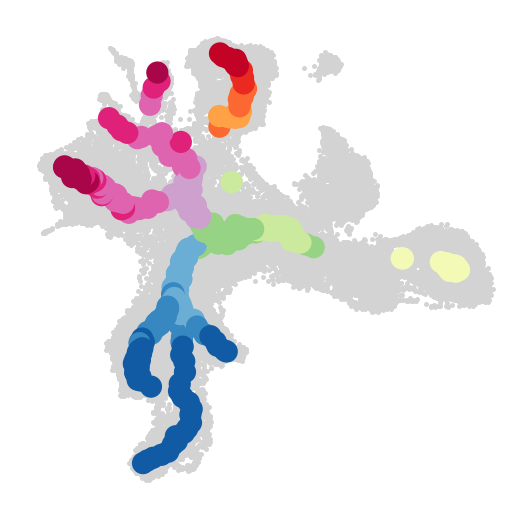

In [16]:

pseudotrail(first=0,last=200)

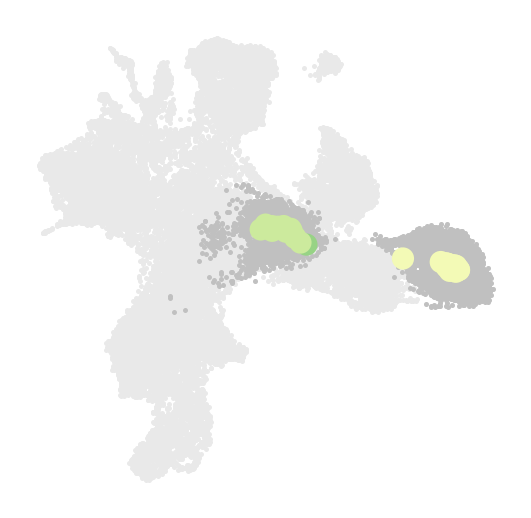

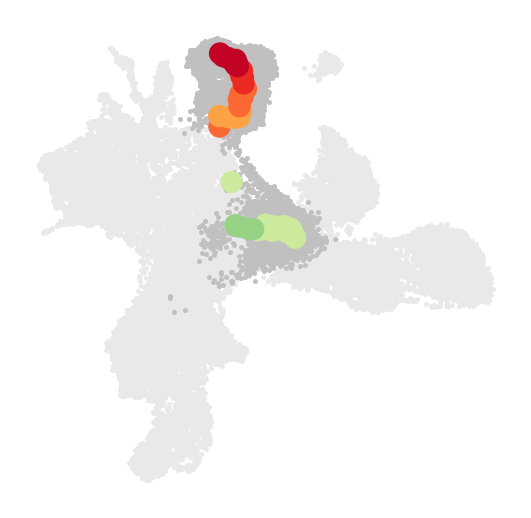

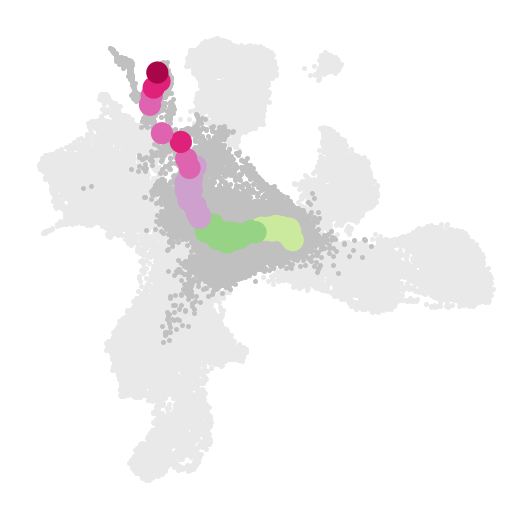

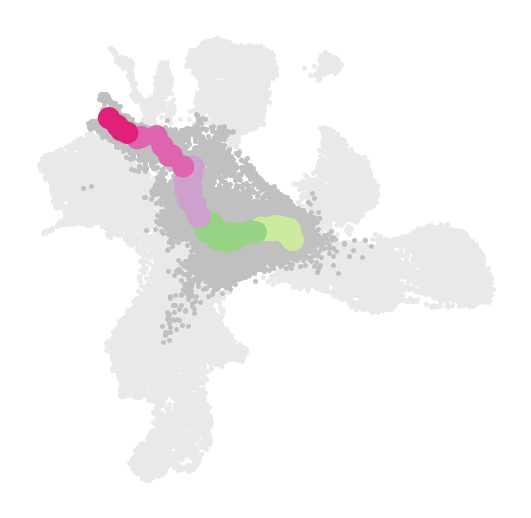

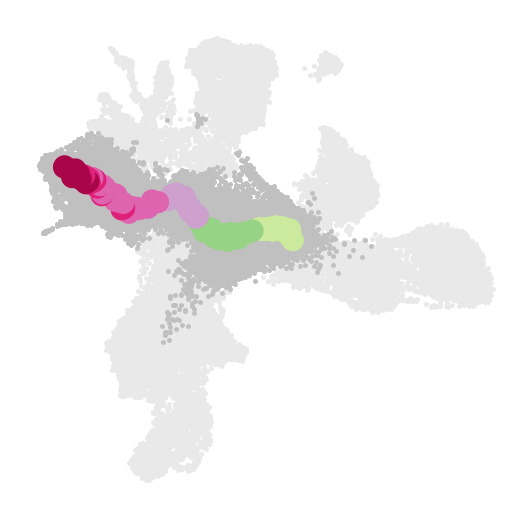

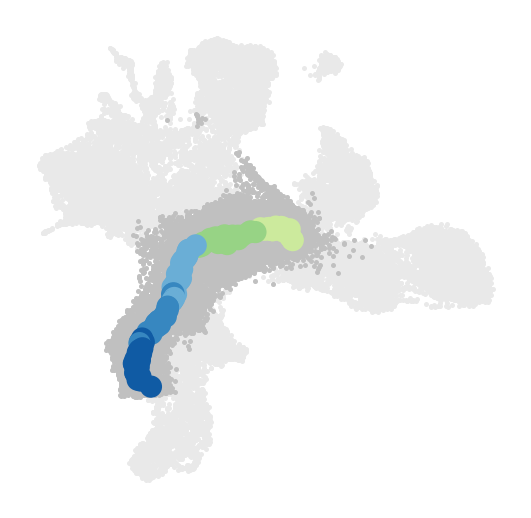

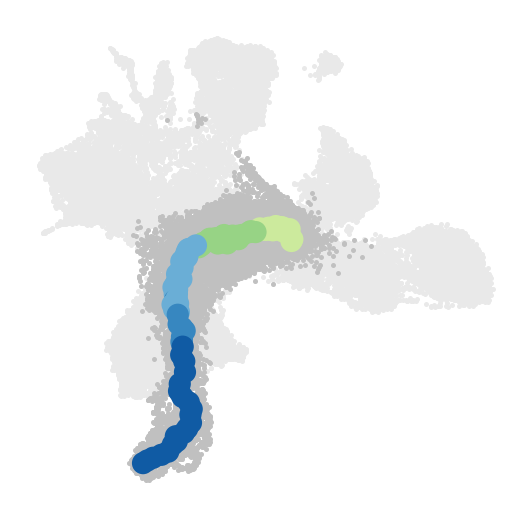

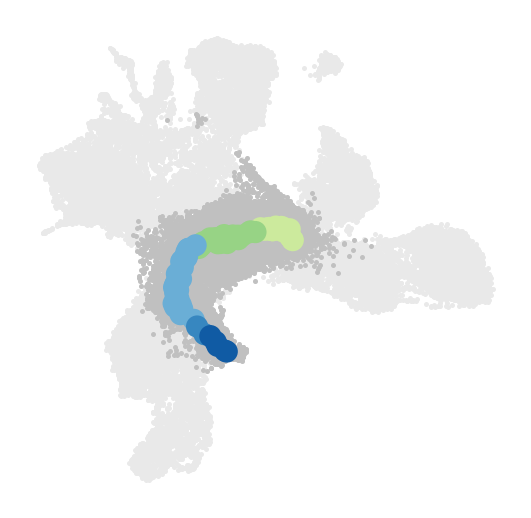

In [17]:
#import lineage distribution for selecting cells to colour

lineages=pd.read_csv("input/20240202_9trajectories.csv", sep = ',', header = 0 ,index_col=0)

#add mESCs to linages and remove reprogramming PGCs 
lineages=lineages[~lineages.index.isin(adata[adata.obs['celltype']=='Reprogramming PGCs'].obs.index)]
ect1_ct=lineages['ect1_ct'].dropna().index
ect2_ct=lineages['ect2_ct'].dropna().index
ect3_ct=lineages['ect3_ct'].dropna().index
mes1_ct=lineages['mes1_ct'].dropna().index
mes2_ct=lineages['mes2_ct'].dropna().index
mes3_ct=lineages['mes3_ct'].dropna().index
end1_ct=adata.obs[adata.obs['celltype'].isin(['Caudal Epiblast','Primitive Streak','Visceral Endoderm','ExE Endoderm'])].index
plu1_ct=adata.obs[adata.obs['celltype'].isin(['mESCs','Caudal Epiblast'])].index



lineageUMAP2(name='plu',lineage='endo1', cellset=plu1_ct, firststep=0, laststep=65)
lineageUMAP2(name='end1',lineage='endo1', cellset=end1_ct, firststep=40, laststep=200)
lineageUMAP2(name='mes3',lineage='mes3', cellset=mes3_ct, firststep=40, laststep=200)
lineageUMAP2(name='mes1',lineage='mes1', cellset=mes1_ct, firststep=40, laststep=200)
lineageUMAP2(name='mes2',lineage='mes2', cellset=mes2_ct, firststep=40, laststep=200)
lineageUMAP2(name='ect3',lineage='ect3', cellset=ect3_ct, firststep=40, laststep=200)
lineageUMAP2(name='ect1',lineage='ect1', cellset=ect1_ct, firststep=40, laststep=200)
lineageUMAP2(name='ect2',lineage='ect2', cellset=ect2_ct, firststep=40, laststep=200)

In [34]:
def histbin(layer, pl, bw, col, quant):
    fig, ax = plt.subplots(figsize=(4, 4))
    plotdata=all_pb_sn2_norm[((all_pb_sn2_norm['step_id'].isin(unique_steps))&(all_pb_sn2_norm['layer']==layer))]
    sns.histplot(data=plotdata, x=pl, hue=version, ax=ax, binwidth=bw, hue_order=[0,1], palette=['Grey',col], legend=False)
    plt.xlim([plotdata[pl].min(), plotdata[pl].quantile(q=quant)])
    ax.grid(False)
    plt.show()

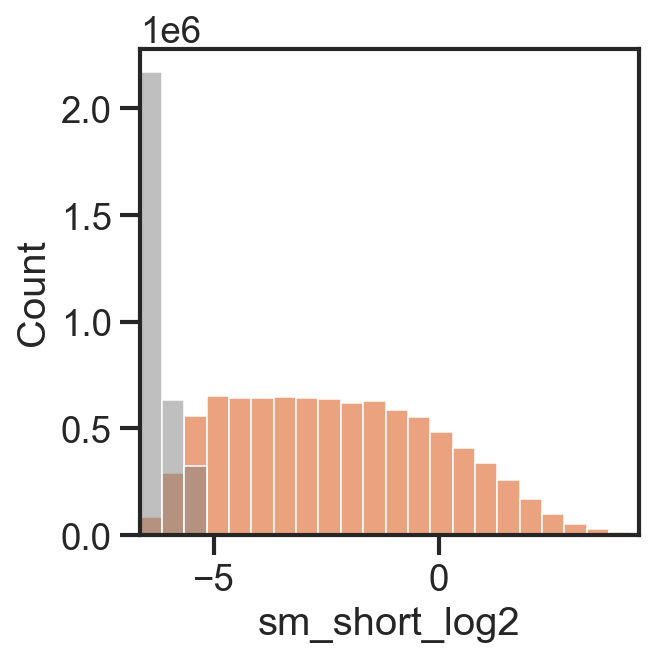

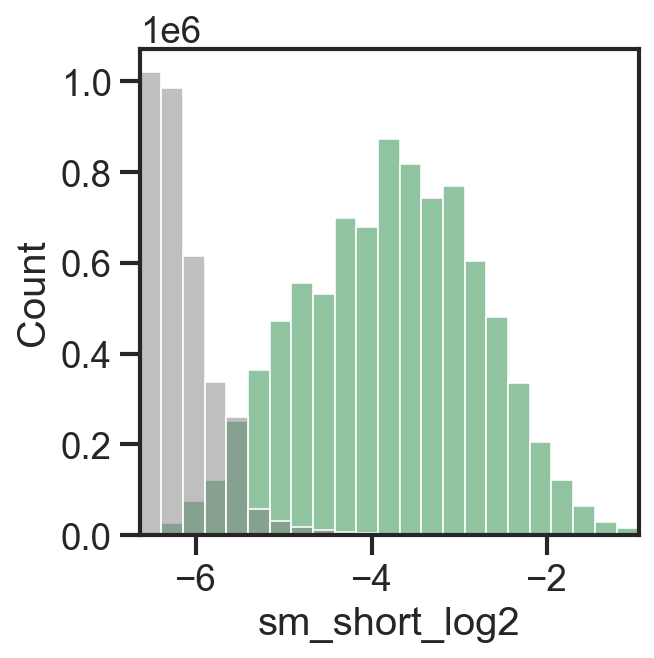

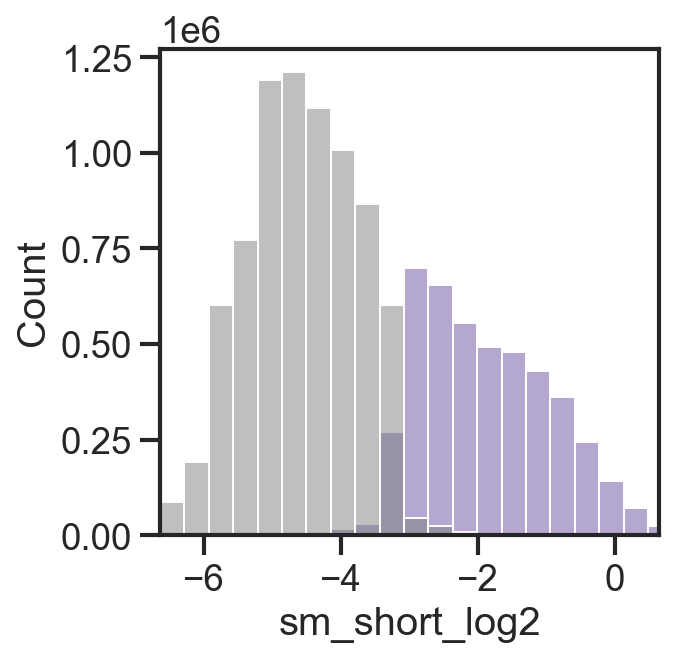

In [35]:
histbin(layer='RNA', pl='sm_short_log2', bw=.5, col=Orange, quant=0.999)

histbin(layer='K4', pl='sm_short_log2', bw=.25, col=Green, quant=0.999)

histbin(layer='K27', pl='sm_short_log2', bw=.35, col=Purple, quant=0.999)


In [20]:
#transform table for states

statetable=all_pb_sn2_norm.pivot(index=['gene','step_id','step','lin'], columns='layer', values=version).reset_index(drop=False)
#calculate 8 states
# 1 nunmarked
# 2 K4
# 3 K27
# 4 K4 K27
# 5 RNA
# 6 K4 RNA 
# 7 K27 RNA
# 8 K4 K27 RNA
statetable['full_state']=9
statetable.loc[((statetable['RNA']==0)&(statetable['K4']==0)&(statetable['K27']==0)),'full_state']=1
statetable.loc[((statetable['RNA']==0)&(statetable['K4']==1)&(statetable['K27']==0)),'full_state']=2
statetable.loc[((statetable['RNA']==0)&(statetable['K4']==0)&(statetable['K27']==1)),'full_state']=3
statetable.loc[((statetable['RNA']==0)&(statetable['K4']==1)&(statetable['K27']==1)),'full_state']=4
statetable.loc[((statetable['RNA']==1)&(statetable['K4']==0)&(statetable['K27']==0)),'full_state']=5
statetable.loc[((statetable['RNA']==1)&(statetable['K4']==1)&(statetable['K27']==0)),'full_state']=6
statetable.loc[((statetable['RNA']==1)&(statetable['K4']==0)&(statetable['K27']==1)),'full_state']=7
statetable.loc[((statetable['RNA']==1)&(statetable['K4']==1)&(statetable['K27']==1)),'full_state']=8

#calculate 4 chromatin states
# 1 nunmarked
# 2 K4
# 3 K27
# 4 K4 K27

statetable['chr_state']=5
statetable.loc[((statetable['K4']==0)&(statetable['K27']==0)),'chr_state']=1
statetable.loc[((statetable['K4']==1)&(statetable['K27']==0)),'chr_state']=2
statetable.loc[((statetable['K4']==0)&(statetable['K27']==1)),'chr_state']=3
statetable.loc[((statetable['K4']==1)&(statetable['K27']==1)),'chr_state']=4

#calculate state fractions
all_meta['step_id']=(all_meta['step'].astype(str))+':'+all_meta['lin']
all_meta['fr_1']=0
all_meta['fr_2']=0
all_meta['fr_3']=0
all_meta['fr_4']=0
all_meta['fr_5']=0
all_meta['fr_6']=0
all_meta['fr_7']=0
all_meta['fr_8']=0
all_meta['fr_RNA']=0
all_meta['fr_K4']=0
all_meta['fr_K27']=0

all_meta.index=all_meta['step_id']

all_meta['fr_1']=((statetable.loc[((statetable['full_state']==1))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_2']=((statetable.loc[((statetable['full_state']==2))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_3']=((statetable.loc[((statetable['full_state']==3))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_4']=((statetable.loc[((statetable['full_state']==4))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_5']=((statetable.loc[((statetable['full_state']==5))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_6']=((statetable.loc[((statetable['full_state']==6))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_7']=((statetable.loc[((statetable['full_state']==7))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_8']=((statetable.loc[((statetable['full_state']==8))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_RNA']=((statetable.loc[((statetable['RNA']==1))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_K4']=((statetable.loc[((statetable['K4']==1))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
all_meta['fr_K27']=((statetable.loc[((statetable['K27']==1))].groupby('step_id').count()['gene'])/(len(statetable['gene'].unique())))*100
    

In [21]:
linday_dict=dict(zip(adata.obs['lin_day'].cat.categories, adata.uns['lin_day_colors']))


# First, map the categorical 'celltype' column to numerical values
celltype_mapping = {cat: i for i, cat in enumerate(list(all_meta['lin2'].unique()))}
all_meta['lin2_col'] = all_meta['lin2'].map(celltype_mapping)

# Now, create the list of colors from dog_color based on the order of the encoded categories
colors = list(map(linday_dict.get, list(all_meta['lin2'].unique())))
cmap = LinearSegmentedColormap.from_list('cmap_lineage', colors, N=len(colors))

In [22]:
# plot single pseudobulks along time
# use ect1 Onecut2, mes1 Hand2, endo1 Podxl, ecdo1 Sox17
def linescatterplot_log(lin, gene):


    linday_dict=dict(zip(adata.obs['lin_day'].cat.categories, adata.uns['lin_day_colors']))
    
    plotmeta=all_meta.copy()
    dayjump=all_meta.loc[((all_meta['lin']==lin)&(all_meta['RT']=='mESCs')),'step'].max()
    
    # First, map the categorical 'celltype' column to numerical values
    celltype_mapping = {cat: i for i, cat in enumerate(list(plotmeta['lin2'].unique()))}
    plotmeta['lin2_col'] = plotmeta['lin2'].map(celltype_mapping)
    
    # Now, create the list of colors from dog_color based on the order of the encoded categories
    colors = list(map(linday_dict.get, list(plotmeta['lin2'].unique())))
    cmap = LinearSegmentedColormap.from_list('cmap_lineage', colors, N=len(colors))
    
    
    fig, ax = plt.subplots(4,2,figsize = (10,10), gridspec_kw={'wspace': 0.05 ,'hspace': 0.1,'height_ratios':(5,5,5,.5),'width_ratios':(dayjump,len(all_pb_sn2_norm[((all_pb_sn2_norm['lin']=='ect1')&(all_pb_sn2_norm['step']>dayjump))]['step'].unique()))})
    
    
    
    #genes=tmpstates.loc[((tmpstates['full_state']==3)&(tmpstates['lin']=='end1')),'gene']
    sns.lineplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='RNA'))], x='step',y='sm_short_log2', ax=ax[0,1], legend=False, color=Orange)
    sns.scatterplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='RNA'))], x='step',y='counts_log2', ax=ax[0,1], hue=version, legend=False, palette=['Grey',Orange],hue_order=[0,1])
    
    ax[0,1].set_ylim(np.log2(.01), max(all_pb_sn2_norm.loc[((all_pb_sn2_norm['layer']=='RNA')&(all_pb_sn2_norm['gene']==gene)),'sm_short_log2'])+1)
    ax[0,1].set_xlim(dayjump+1, len(all_pb_sn2_norm[all_pb_sn2_norm['lin']==lin]['step'].unique()))
    ax[0,1].tick_params(labelbottom=False, bottom=False)
    ax[0,1].tick_params(labelleft=False, left=False)
    
    
    ax[0,1].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.lineplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='K4'))], x='step',y='sm_short', ax=ax[1,1], legend=False, color=Green)
    sns.scatterplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='K4'))], x='step',y='counts', ax=ax[1,1], hue=version, legend=False, palette=['Grey',Green],hue_order=[0,1])
    
    ax[1,1].set_ylim(0, max(all_pb_sn2_norm.loc[((all_pb_sn2_norm['layer']=='K4')&(all_pb_sn2_norm['gene']==gene)),'sm_short'])*1.3)
    ax[1,1].set_xlim(dayjump+1, len(all_pb_sn2_norm[all_pb_sn2_norm['lin']==lin]['step'].unique()))
    ax[1,1].tick_params(labelbottom=False, bottom=False)
    ax[1,1].tick_params(labelbottom=False, bottom=False)
    ax[1,1].tick_params(labelleft=False, left=False)
    ax[1,1].set(xlabel='',
           ylabel='',
           title='')
    
    sns.lineplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='K27'))], x='step',y='sm_short', ax=ax[2,1], legend=False, color=Purple)
    sns.scatterplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='K27'))], x='step',y='counts', hue=version,ax=ax[2,1], legend=False, palette=['Grey',Purple],hue_order=[0,1])
    
    ax[2,1].set_ylim(0, max(all_pb_sn2_norm.loc[((all_pb_sn2_norm['layer']=='K27')&(all_pb_sn2_norm['gene']==gene)),'sm_short'])*1.3)
    ax[2,1].set_xlim(dayjump+1, len(all_pb_sn2_norm[all_pb_sn2_norm['lin']==lin]['step'].unique()))
    ax[2,1].tick_params(labelbottom=False, bottom=False)
    ax[2,1].tick_params(labelleft=False, left=False)
    
    
    ax[2,1].set(xlabel='',
           ylabel='',
           title='')
    
    # Extract the filtered 'celltype_encoded' data to use in imshow
    celltype_data = plotmeta.loc[((plotmeta['lin']==lin)&(plotmeta['step']>dayjump)), 'lin2_col'].values.reshape(-1, 1)
    
    
    ax[3,1].imshow(celltype_data.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
    
    
    ax[3,1].tick_params(labelbottom=False, bottom=False)
    ax[3,1].tick_params(labelleft=False, left=False)
    
    
    
    sns.lineplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='RNA'))], x='step',y='sm_short_log2', ax=ax[0,0], legend=False, color=Orange)
    sns.scatterplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='RNA'))], x='step',y='counts_log2', ax=ax[0,0], hue=version, legend=False, palette=['Grey',Orange],hue_order=[0,1])
    
    ax[0,0].set_ylim(np.log2(.01), max(all_pb_sn2_norm.loc[((all_pb_sn2_norm['layer']=='RNA')&(all_pb_sn2_norm['gene']==gene)),'sm_short_log2'])+1)
    ax[0,0].set_xlim(0, dayjump)
    
    ax[0,0].tick_params(labelbottom=False, bottom=False)
    
    ax[0,0].set(xlabel='',
           ylabel='RNA log2',
           title=gene)
    
    
    
    
    sns.lineplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='K4'))], x='step',y='sm_short', ax=ax[1,0], legend=False, color=Green)
    sns.scatterplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='K4'))], x='step',y='counts', ax=ax[1,0], hue=version, legend=False, palette=['Grey',Green],hue_order=[0,1])
    
    ax[1,0].set_ylim(0, max(all_pb_sn2_norm.loc[((all_pb_sn2_norm['layer']=='K4')&(all_pb_sn2_norm['gene']==gene)),'sm_short'])*1.3)
    ax[1,0].set_xlim(0, dayjump)
    ax[1,0].tick_params(labelbottom=False, bottom=False)
    ax[1,0].tick_params(labelbottom=False, bottom=False)
    ax[1,0].set(xlabel='',
           ylabel='H3K4me3',
           title='')
    
    sns.lineplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='K27'))], x='step',y='sm_short', ax=ax[2,0], legend=False, color=Purple)
    sns.scatterplot(data=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['gene']==gene)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='K27'))], x='step',y='counts', hue=version,ax=ax[2,0], legend=False, palette=['Grey',Purple],hue_order=[0,1])
    
    ax[2,0].set_ylim(0, max(all_pb_sn2_norm.loc[((all_pb_sn2_norm['layer']=='K27')&(all_pb_sn2_norm['gene']==gene)),'sm_short'])*1.3)
    ax[2,0].set_xlim(0, dayjump)
    ax[2,0].tick_params(labelbottom=False, bottom=False)
    
    
    ax[2,0].set(xlabel='',
           ylabel='H3K27me3',
           title='')
    
    # Extract the filtered 'celltype_encoded' data to use in imshow
    celltype_data = plotmeta.loc[((plotmeta['lin']==lin)&(plotmeta['step']<=dayjump)), 'lin2_col'].values.reshape(-1, 1)
    
    
    ax[3,0].imshow(celltype_data.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
    
    
    
    ax[3,0].tick_params(labelbottom=False, bottom=False)
    ax[3,0].tick_params(labelleft=False, left=False)
    
    
    name=folder+'Fig5e_PT_scatter_log_'+gene+'_'+lin+'_sm_full.png'
    plt.savefig(name, dpi=300, format='png', bbox_inches='tight')
    plt.show()
    
    

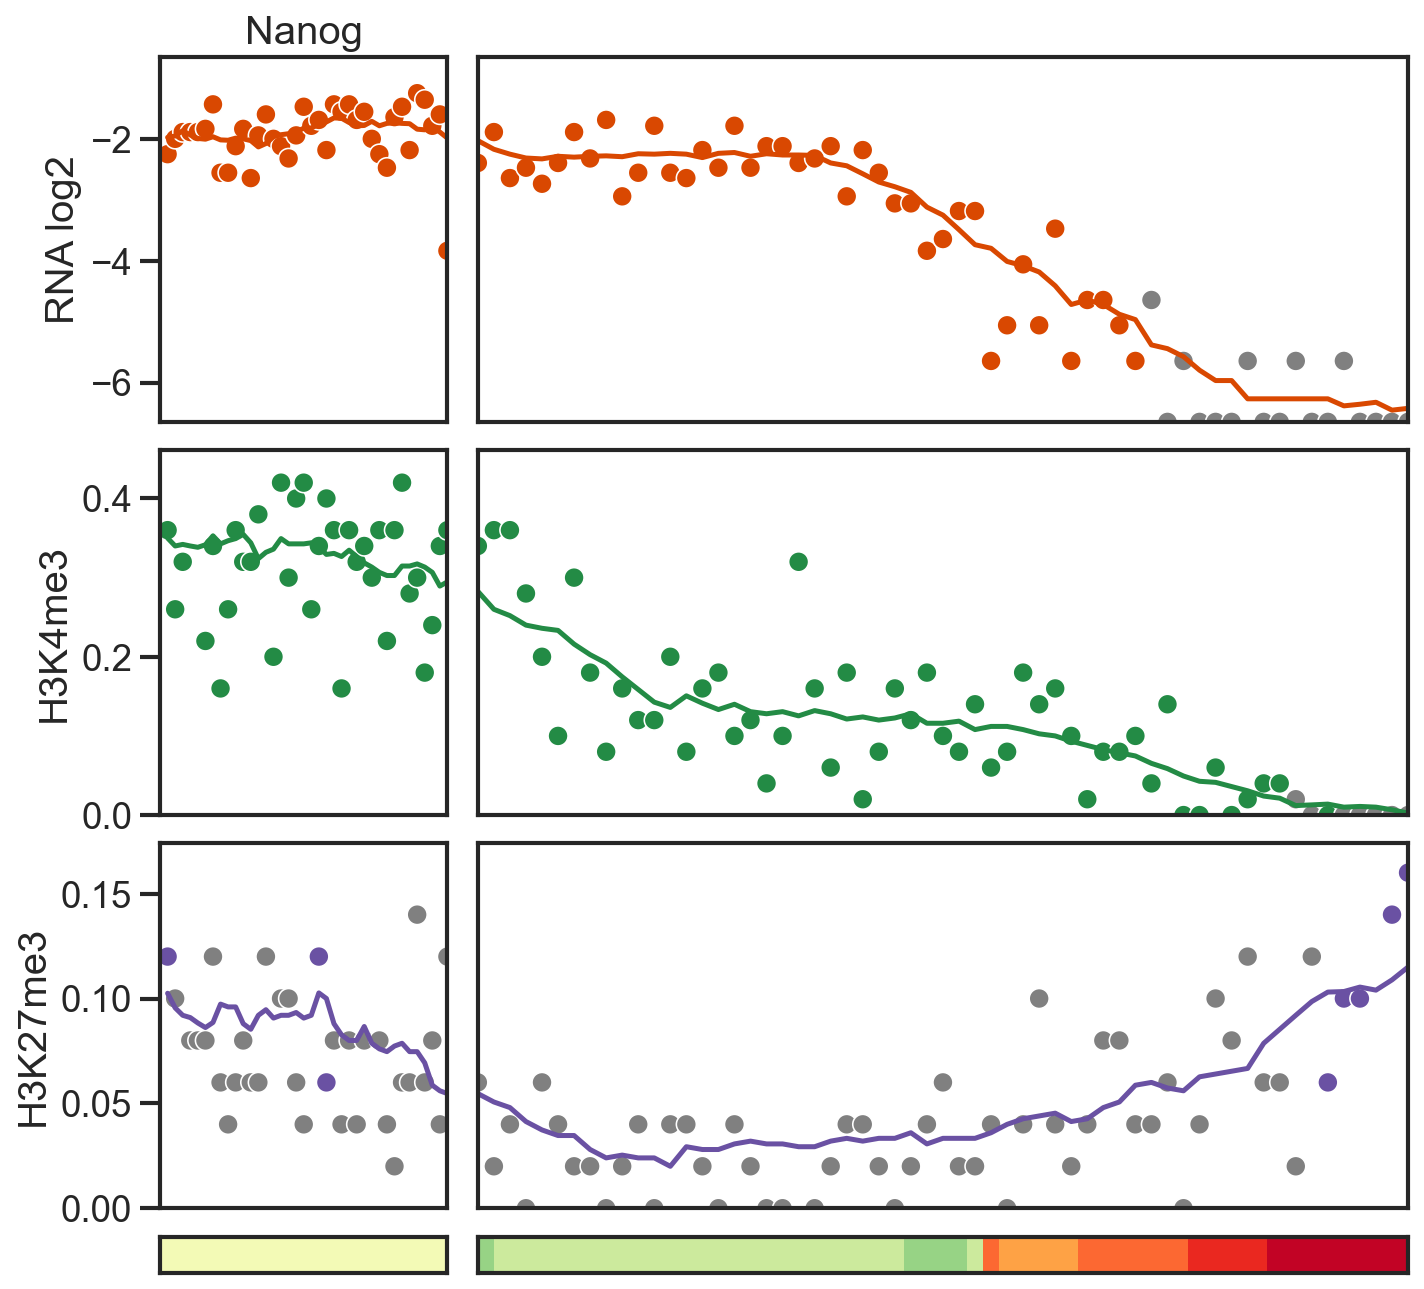

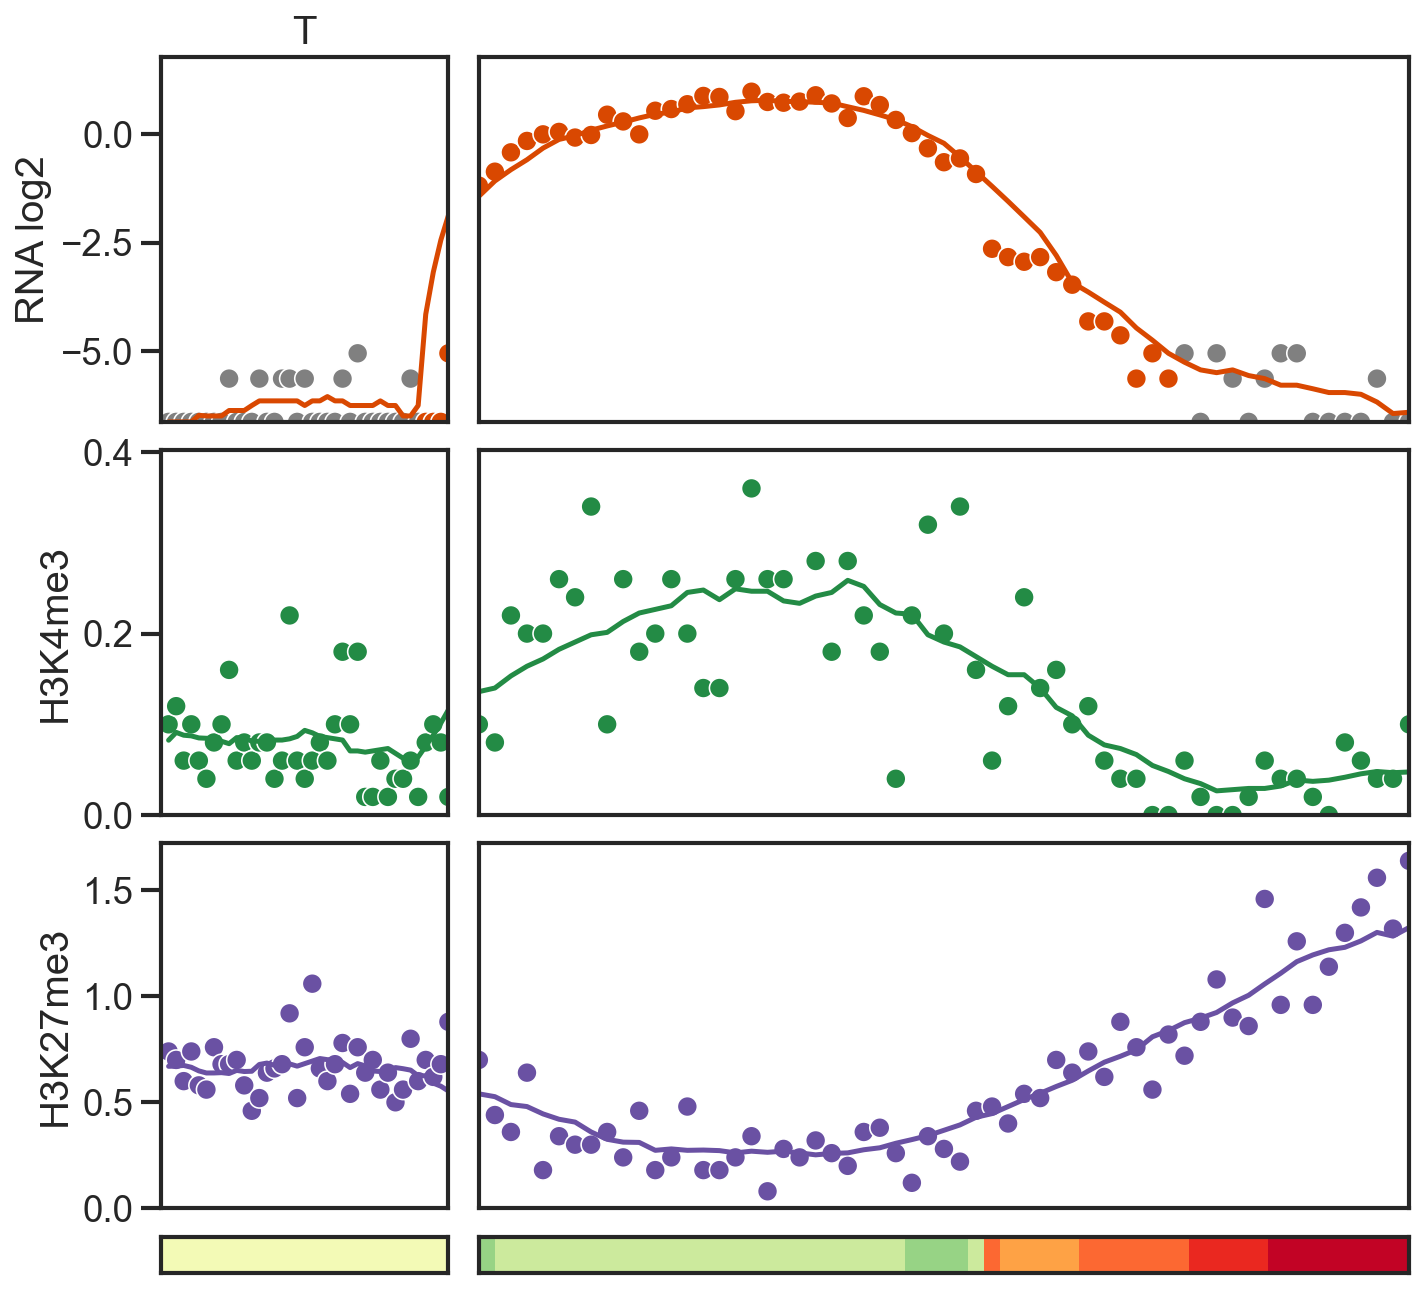

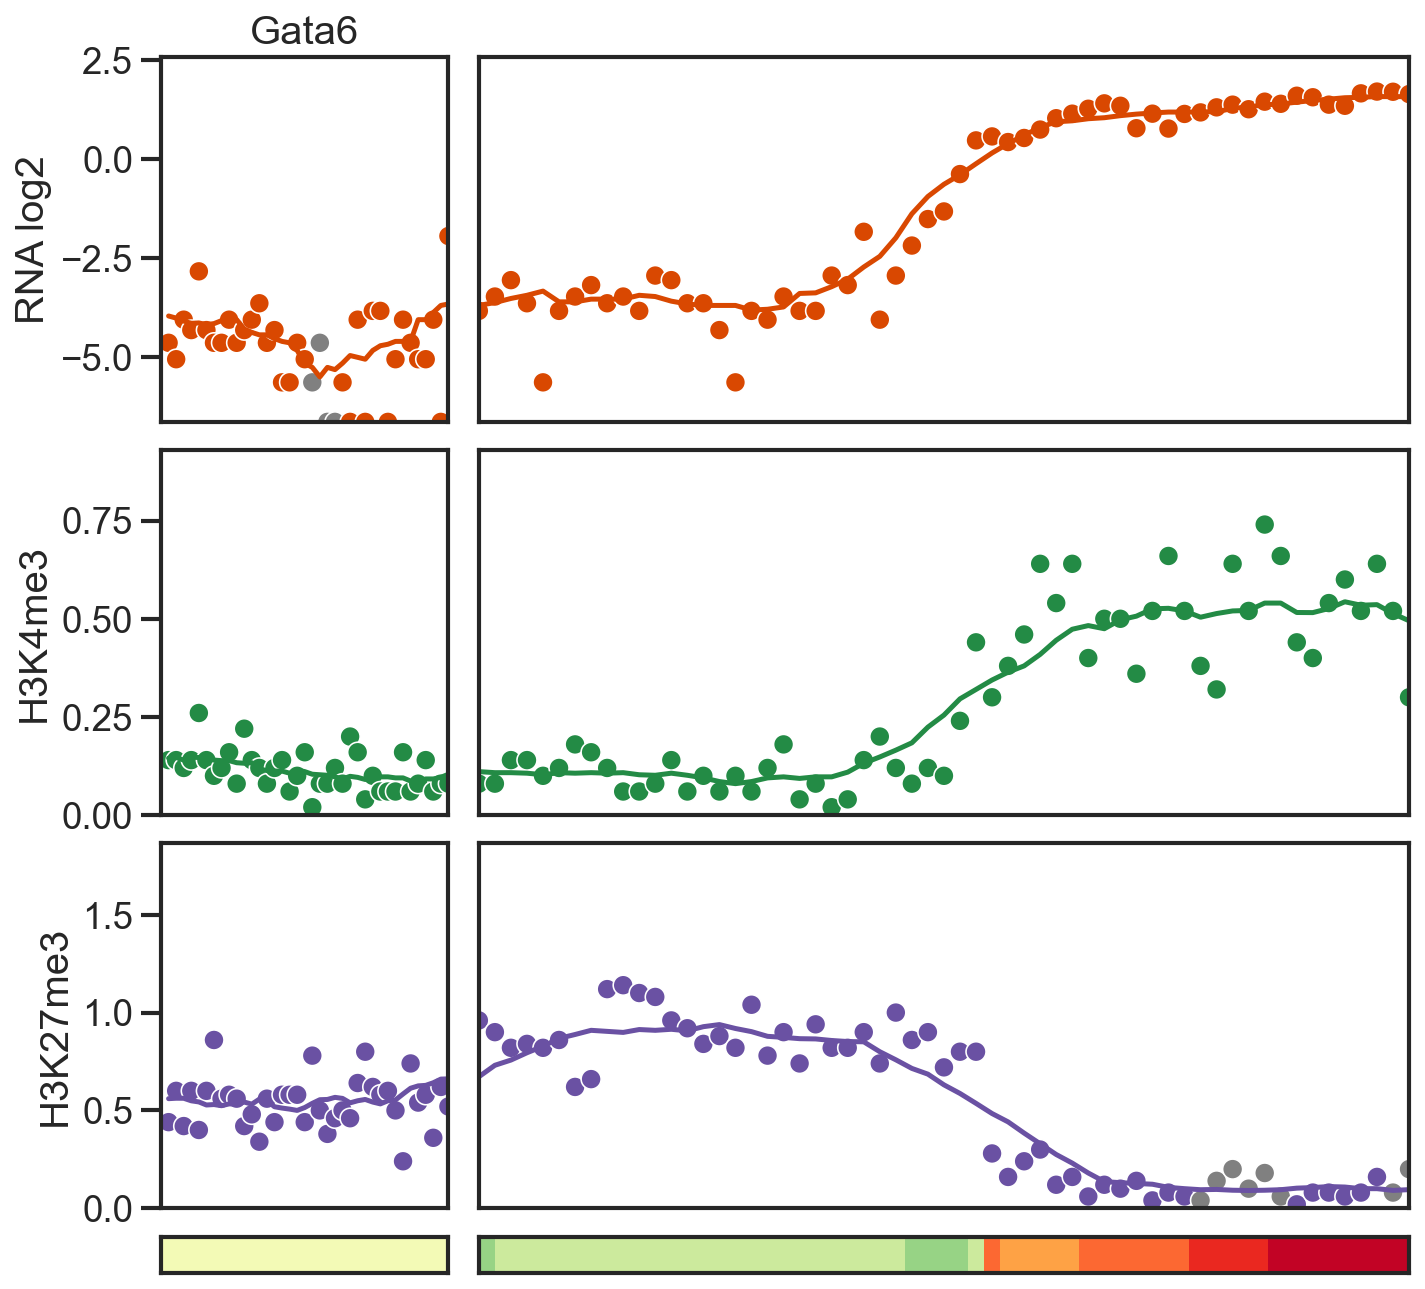

In [36]:

linescatterplot_log('endo1','Nanog')
linescatterplot_log('endo1','T')
linescatterplot_log('endo1','Gata6')


In [24]:
#plot transition matrix for all genes, start, end can be slected, end ESC 40, end pluri 70
def transitiondotplot(name, geneset=statetable['gene'].unique(), onlychanging=False, huemax=100, sizemax=6000):

    fig, axes = plt.subplots(3, 3, figsize=(15, 15), gridspec_kw={'hspace': 0.3, 'wspace': 0.3, 'height_ratios':(5,5,5)})
    

    axes = axes.flatten()

    
    
    firststep=1
    laststep=60
    tmp1=statetable[((statetable['step']<=laststep)&(statetable['gene'].isin(geneset)))].copy()
    
    linage='ect1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      
    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start', hue='fraction',edgecolor='gray',linewidth=1, ax=axes[0], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[0].set(xlabel='',
       ylabel='',
       title='Plu')
    
    sns.heatmap(emptydata, ax=axes[1], cbar=False, annot=False, linewidths=0, linecolor="white")
    axes[1].tick_params(labelleft=False, left=False)
    axes[1].tick_params(labelbottom=False, bottom=False)
    axes[1].set(xlabel='',
           ylabel='',
           title='')
    
    firststep=50
    laststep=200
    tmp1=statetable[((statetable['step']<=laststep)&(statetable['gene'].isin(geneset)))].copy()
    
    linage='endo1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[2], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis')
    axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    axes[2].set(xlabel='',
       ylabel='',
       title='End1')
    
    
    linage='mes1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[3], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[3].set(xlabel='',
       ylabel='',
       title='Mes1')
    
    linage='mes2'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[4], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[4].set(xlabel='',
       ylabel='',
       title='Mes2')
    
    linage='mes3'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[5], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[5].set(xlabel='',
       ylabel='',
       title='Mes3')
    
    
    linage='ect1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[6], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[6].set(xlabel='',
       ylabel='',
       title='Ect1')
    
    
    
    linage='ect2'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[7], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[7].set(xlabel='',
       ylabel='',
       title='Ect2')
    
    linage='ect3'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[8], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[8].set(xlabel='',
       ylabel='',
       title='Ect3')
    
    
    
    
    filename=folder+'Fig5f_transitionmatrix_'+name+str(onlychanging)+'.pdf'
    plt.savefig(filename, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


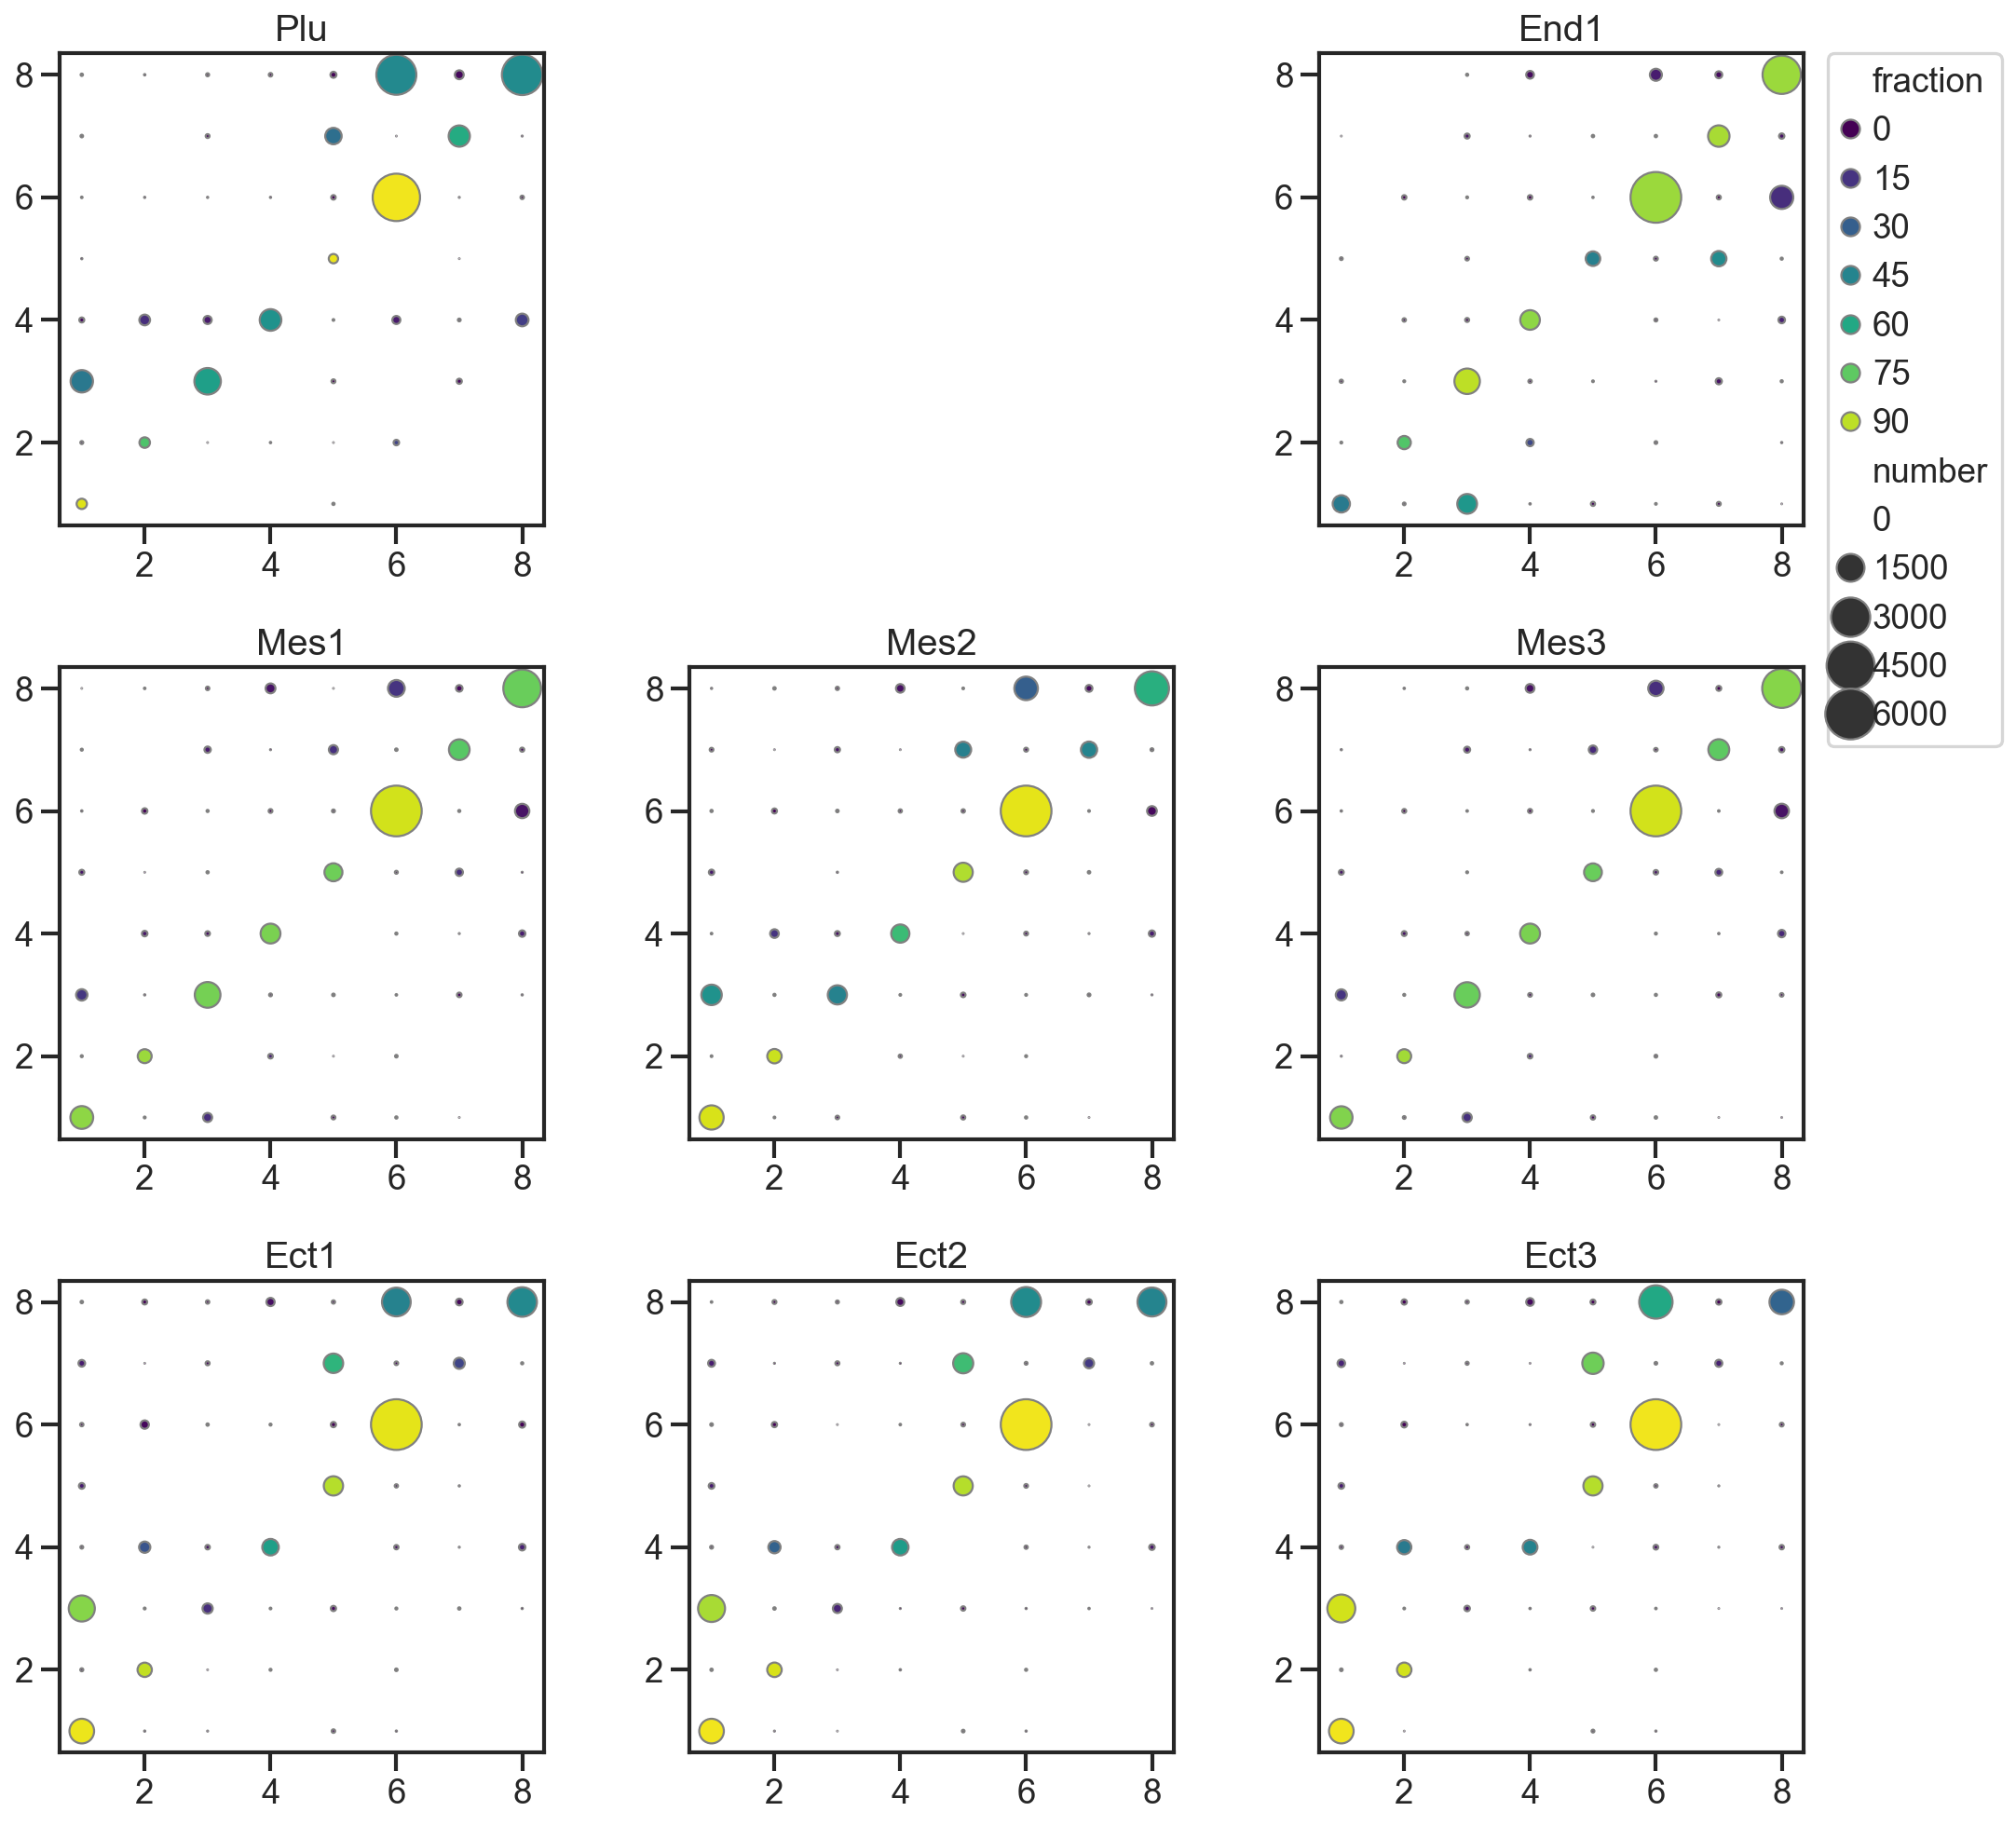

In [25]:
transitiondotplot('allgenes', geneset=statetable['gene'].unique(), onlychanging=False, huemax=100, sizemax=5000)


In [37]:
def singlecellpseudotimeheatmap_log(lin, firststep, laststep, transitions, onlychanging=False, hightadjust=True, geneset=statetable['gene'].unique()):

    space=5    #space between plots
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
    
        trans_temp=pd.DataFrame(columns=['start','end','number'])
        dayjump=all_meta.loc[((all_meta['RT']=='mESCs')),'step'].max()
          
        tmp2=statetable[((statetable['lin']==lin)&(statetable['step']<=laststep)&(statetable['step']>=firststep)&(statetable['gene'].isin(geneset)))].copy()
            
        startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
        endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
            
        trans_temp=pd.DataFrame(columns=['start','end','number'])
        for start in range(0,8):
            for end in range(0,8):
                    
                tmp3=startset[startset==start+1].index
                changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
                results = pd.DataFrame({
                    'start': [start+1],
                    'end': [end+1],
                    'number': [changing],
                })
                trans_temp=pd.concat([trans_temp, results], ignore_index=True)      
        if onlychanging==True:
            trans_temp.loc[(trans_temp['start']==trans_temp['end']),['number']]=0
        
        trans_temp=trans_temp.sort_values(by='number',ascending=False).reset_index(drop=True)
        
        stepmax=(all_pb_sn2_norm.loc[all_pb_sn2_norm['lin']==lin,'step'].max())-dayjump
        wr=[]
        for t in range(0, 3):
            wr.append(30)
            wr.append(stepmax)
            wr.append(space)
        hr=[]
        for h in range(0, transitions):
            l=startset[startset==trans_temp.loc[h,'start']].index
            l=endset[((endset==trans_temp.loc[h,'end'])&(endset.index.isin(l)))] 
            hr.append(len(l))
        hr.extend([sum(hr)*.01, sum(hr)*.01])
        
        
        RNAplotdatalog=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='RNA'))].pivot(index='gene', columns='step', values='sm_short_log2')
        RNAplotdata=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='RNA'))].pivot(index='gene', columns='step', values='sm_short')
        K4plotdata=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='K4'))].pivot(index='gene', columns='step', values='sm_short')
        K27plotdata=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']>dayjump)&(all_pb_sn2_norm['layer']=='K27'))].pivot(index='gene', columns='step', values='sm_short')
        
        RNAplotdata1log=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='RNA'))].pivot(index='gene', columns='step', values='sm_short_log2')
        RNAplotdata1=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='RNA'))].pivot(index='gene', columns='step', values='sm_short')
        K4plotdata1=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='K4'))].pivot(index='gene', columns='step', values='sm_short')
        K27plotdata1=all_pb_sn2_norm[((all_pb_sn2_norm['lin']==lin)&(all_pb_sn2_norm['step']<=dayjump)&(all_pb_sn2_norm['layer']=='K27'))].pivot(index='gene', columns='step', values='sm_short')
        
        data = np.full((10, 10), np.nan)
        k4vmax=all_pb_sn2_norm.loc[(all_pb_sn2_norm['layer']=='K4'),'sm_short'].quantile(q=0.96)
        k27vmax=all_pb_sn2_norm.loc[(all_pb_sn2_norm['layer']=='K27'),'sm_short'].quantile(q=0.96)
        RNAvmin=0
        RNAvmax=all_pb_sn2_norm.loc[(all_pb_sn2_norm['layer']=='RNA'),'sm_short'].quantile(q=0.88)
        RNAvmaxlog=all_pb_sn2_norm.loc[(all_pb_sn2_norm['layer']=='RNA'),'sm_short_log2'].max()
        RNAvminlog=all_pb_sn2_norm.loc[(all_pb_sn2_norm['layer']=='RNA'),'sm_short_log2'].min()
        
        if hightadjust==True:
            fig, axes = plt.subplots((transitions+2), 8, figsize=(8, 16), gridspec_kw={'hspace': 0.03 ,'wspace': 0.05, 'width_ratios':wr[:-1],'height_ratios':hr})
        else:
            fig, axes = plt.subplots((transitions+2), 8, figsize=(8, 16), gridspec_kw={'hspace': 0.03 ,'wspace': 0.05, 'width_ratios':wr[:-1],'height_ratios':([100]*transitions)+([10]*2)})
        
        axes = axes.flatten()
        
        for h in range(0, transitions):
            l1=startset[startset==trans_temp.loc[h,'start']].index
            l1=endset[((endset==trans_temp.loc[h,'end'])&(endset.index.isin(l1)))].index

            ylabel=str(trans_temp.loc[h,'start'])+'-'+str(trans_temp.loc[h,'end'])
        

            
          
            
            sns.heatmap(RNAplotdata1log.loc[l1], ax=axes[h*8+0], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
            axes[h*8+0].tick_params(labelleft=False, left=False)
            axes[h*8+0].tick_params(labelbottom=False, bottom=False)
            axes[h*8+0].set(xlabel='',
                   ylabel=ylabel,
                   title='')
            
            sns.heatmap(RNAplotdatalog.loc[l1], ax=axes[h*8+1], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
            axes[h*8+1].tick_params(labelleft=False, left=False)
            axes[h*8+1].tick_params(labelbottom=False, bottom=False)
            axes[h*8+1].set(xlabel='',
                   ylabel='',
                   title='')
            
            sns.heatmap(data, ax=axes[h*8+2], cbar=False, annot=False, linewidths=0, linecolor="white")
            axes[h*8+2].tick_params(labelleft=False, left=False)
            axes[h*8+2].tick_params(labelbottom=False, bottom=False)
            axes[h*8+2].set(xlabel='',
                   ylabel='',
                   title='')
            
            sns.heatmap(K4plotdata1.loc[l1], ax=axes[h*8+3], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
            axes[h*8+3].tick_params(labelleft=False, left=False)
            axes[h*8+3].tick_params(labelbottom=False, bottom=False)
            axes[h*8+3].set(xlabel='',
                   ylabel='',
                   title='')
            
            sns.heatmap(K4plotdata.loc[l1], ax=axes[h*8+4], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
            axes[h*8+4].tick_params(labelleft=False, left=False)
            axes[h*8+4].tick_params(labelbottom=False, bottom=False)
            axes[h*8+4].set(xlabel='',
                   ylabel='',
                   title='')
            
            sns.heatmap(data, ax=axes[h*8+5], cbar=False, annot=False, linewidths=0, linecolor="white")
            axes[h*8+5].tick_params(labelleft=False, left=False)
            axes[h*8+5].tick_params(labelbottom=False, bottom=False)
            axes[h*8+5].set(xlabel='',
                   ylabel='',
                   title='')
            
            sns.heatmap(K27plotdata1.loc[l1], ax=axes[h*8+6], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
            axes[h*8+6].tick_params(labelleft=False, left=False)
            axes[h*8+6].tick_params(labelbottom=False, bottom=False)
            axes[h*8+6].set(xlabel='',
                   ylabel='',
                   title='')
            
            sns.heatmap(K27plotdata.loc[l1], ax=axes[h*8+7], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
            axes[h*8+7].tick_params(labelleft=False, left=False)
            axes[h*8+7].tick_params(labelbottom=False, bottom=False)
            axes[h*8+7].set(xlabel='',
                   ylabel='',
                   title='')
        
        
        #add annotations
        plotmeta=all_meta.copy()
        celltype_data1 = plotmeta.loc[((plotmeta['lin']==lin)&(plotmeta['step']<=dayjump)), 'lin2_col'].values.reshape(-1, 1)
        celltype_data2 = plotmeta.loc[((plotmeta['lin']==lin)&(plotmeta['step']>dayjump)), 'lin2_col'].values.reshape(-1, 1)
        
        loc=(transitions*8)
        axes[loc].imshow(celltype_data1.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].set_frame_on(False)
        loc=loc+1
        axes[loc].imshow(celltype_data2.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].set_frame_on(False)
        loc=loc+1
        sns.heatmap(data, ax=axes[loc], cbar=False, annot=False, linewidths=0, linecolor="white")
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].set(xlabel='',
               ylabel='',
               title='')
        
        loc=loc+1
        axes[loc].imshow(celltype_data1.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].set_frame_on(False)
        loc=loc+1
        axes[loc].imshow(celltype_data2.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].set_frame_on(False)
        loc=loc+1
        sns.heatmap(data, ax=axes[loc], cbar=False, annot=False, linewidths=0, linecolor="white")
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].set(xlabel='',
               ylabel='',
               title='')
        loc=loc+1
        axes[loc].imshow(celltype_data1.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].set_frame_on(False)
        loc=loc+1
        axes[loc].imshow(celltype_data2.T,interpolation='none', aspect='auto', cmap=cmap, vmin=plotmeta['lin2_col'].min(),vmax=plotmeta['lin2_col'].max())
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].set_frame_on(False)
        loc=loc+1
        sns.heatmap(data, ax=axes[loc], cbar=False, annot=False, linewidths=0, linecolor="white")
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].set(xlabel='',
               ylabel='',
               title='')
        loc=loc+1
        
        gradient = np.linspace(round(RNAvminlog,0), round(RNAvmaxlog,0)).reshape(1, -1)
        axes[loc].imshow(gradient, aspect="auto", cmap=oranges_r)
        axes[loc].set_yticks([])
        axes[loc].set_frame_on(False)
        axes[loc].set_xticks([0, gradient.size-1])  # Positions along the gradient
        axes[loc].set_xticklabels([round(RNAvminlog,0), round(RNAvmaxlog,0)])  # Labels
        loc=loc+1
        sns.heatmap(data, ax=axes[loc], cbar=False, annot=False, linewidths=0, linecolor="white")
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].set(xlabel='',
               ylabel='',
               title='')
        loc=loc+1
        sns.heatmap(data, ax=axes[loc], cbar=False, annot=False, linewidths=0, linecolor="white")
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].set(xlabel='',
               ylabel='',
               title='')
        loc=loc+1
        gradient = np.linspace(0, round(k4vmax,1)).reshape(1, -1)
        axes[loc].imshow(gradient, aspect="auto", cmap=greens_r)
        axes[loc].set_yticks([])
        axes[loc].set_frame_on(False)
        axes[loc].set_xticks([0, gradient.size-1])  # Positions along the gradient
        axes[loc].set_xticklabels([0, round(k4vmax,1)])  # Labels
        loc=loc+1
        sns.heatmap(data, ax=axes[loc], cbar=False, annot=False, linewidths=0, linecolor="white")
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].set(xlabel='',
               ylabel='',
               title='')
        loc=loc+1
        sns.heatmap(data, ax=axes[loc], cbar=False, annot=False, linewidths=0, linecolor="white")
        axes[loc].tick_params(labelleft=False, left=False)
        axes[loc].tick_params(labelbottom=False, bottom=False)
        axes[loc].set(xlabel='',
               ylabel='',
               title='')
        loc=loc+1
        gradient = np.linspace(0, round(k27vmax,1)).reshape(1, -1)
        axes[loc].imshow(gradient, aspect="auto", cmap=purples_r)
        axes[loc].set_yticks([])
        axes[loc].set_frame_on(False)
        axes[loc].set_xticks([0, gradient.size-1])  # Positions along the gradient
        axes[loc].set_xticklabels([0, round(k27vmax,1)])  # Labels
    
    filename = folder + 'FigS5f_Pseudotime_heatmap_log_gene_state_sel_trans' + '_' + str(transitions) + '_' + lin + '_' + str(firststep) + 'to' + str(laststep)
    if onlychanging:
        filename += '_onlychanging'
    if hightadjust:
        filename += '_hightadjust'
    filename += '.png'
    plt.savefig(filename, dpi=300, format='png', bbox_inches='tight')
    plt.show()
    


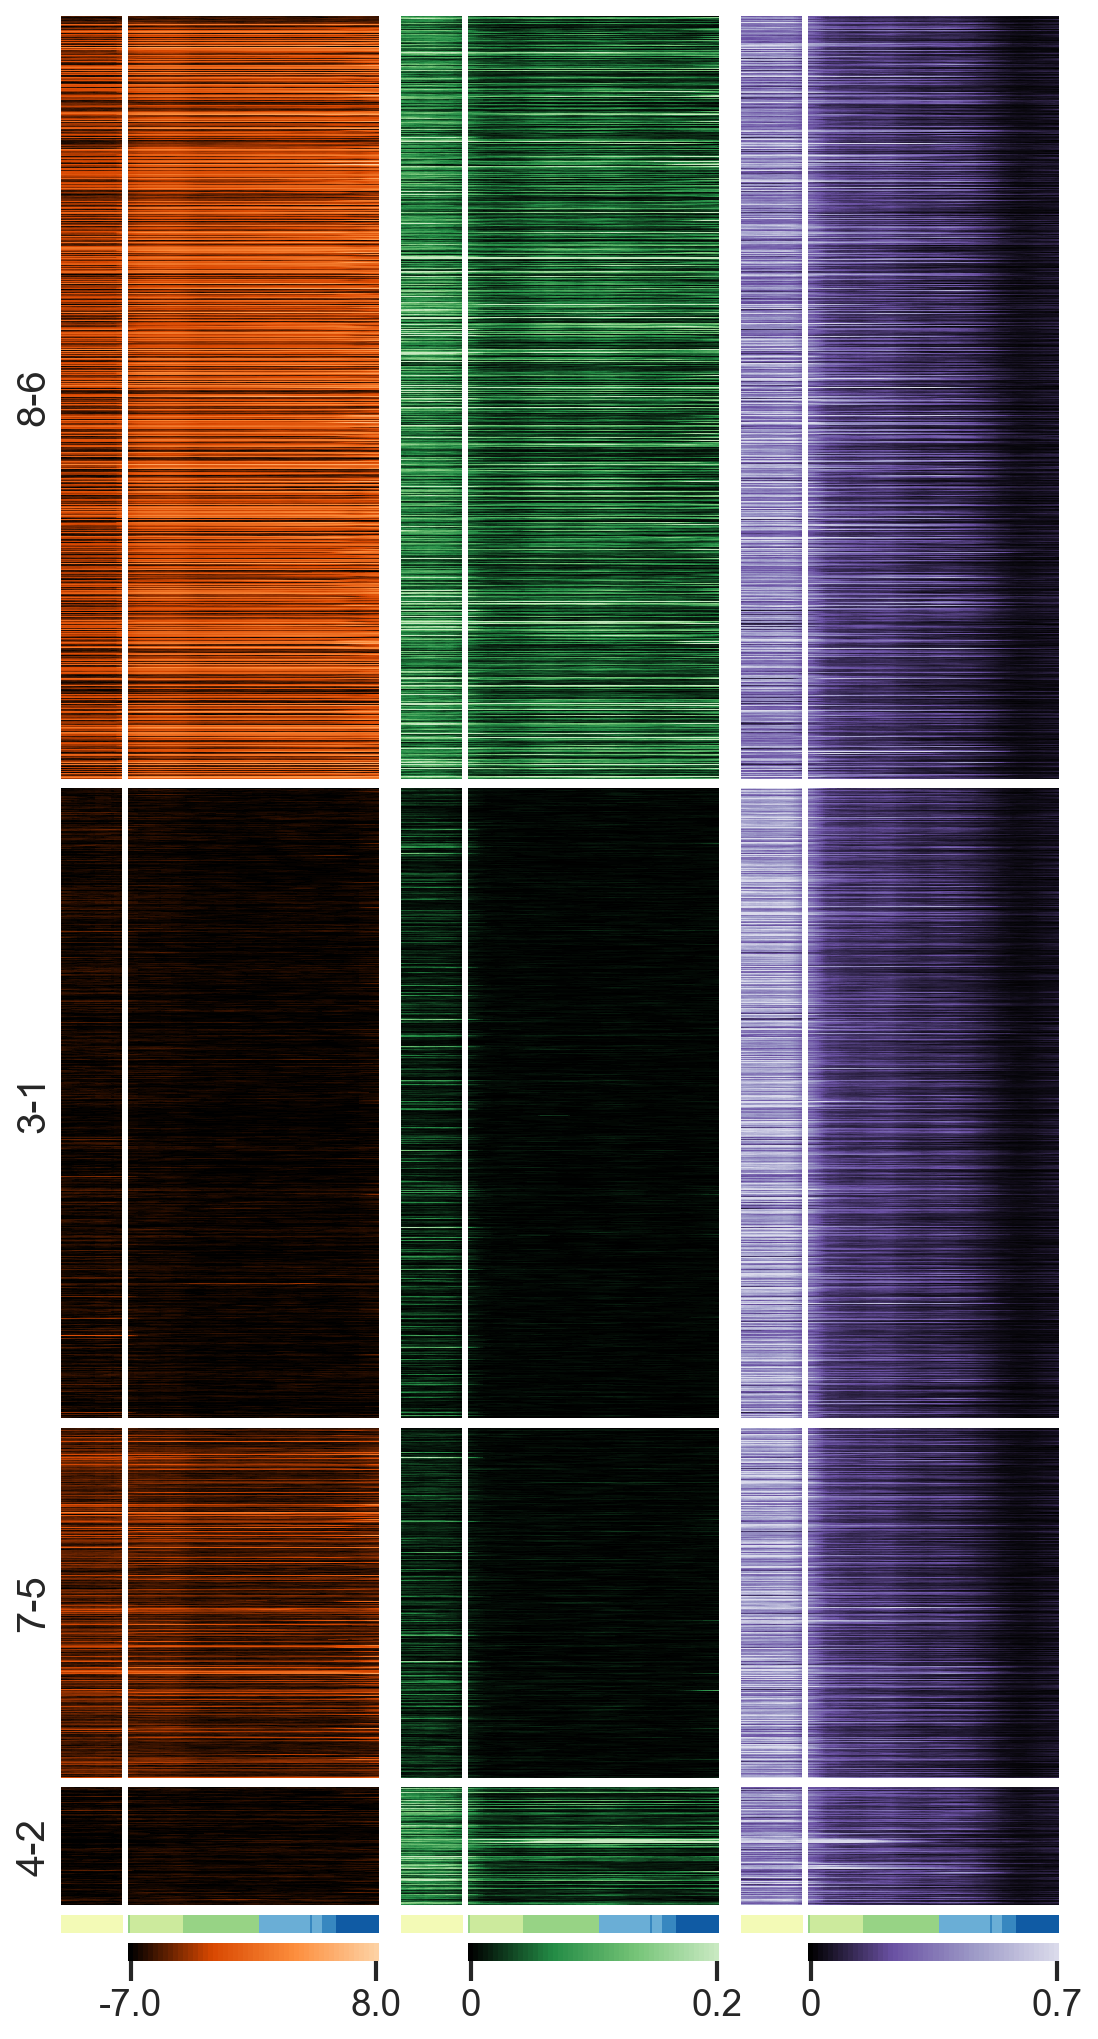

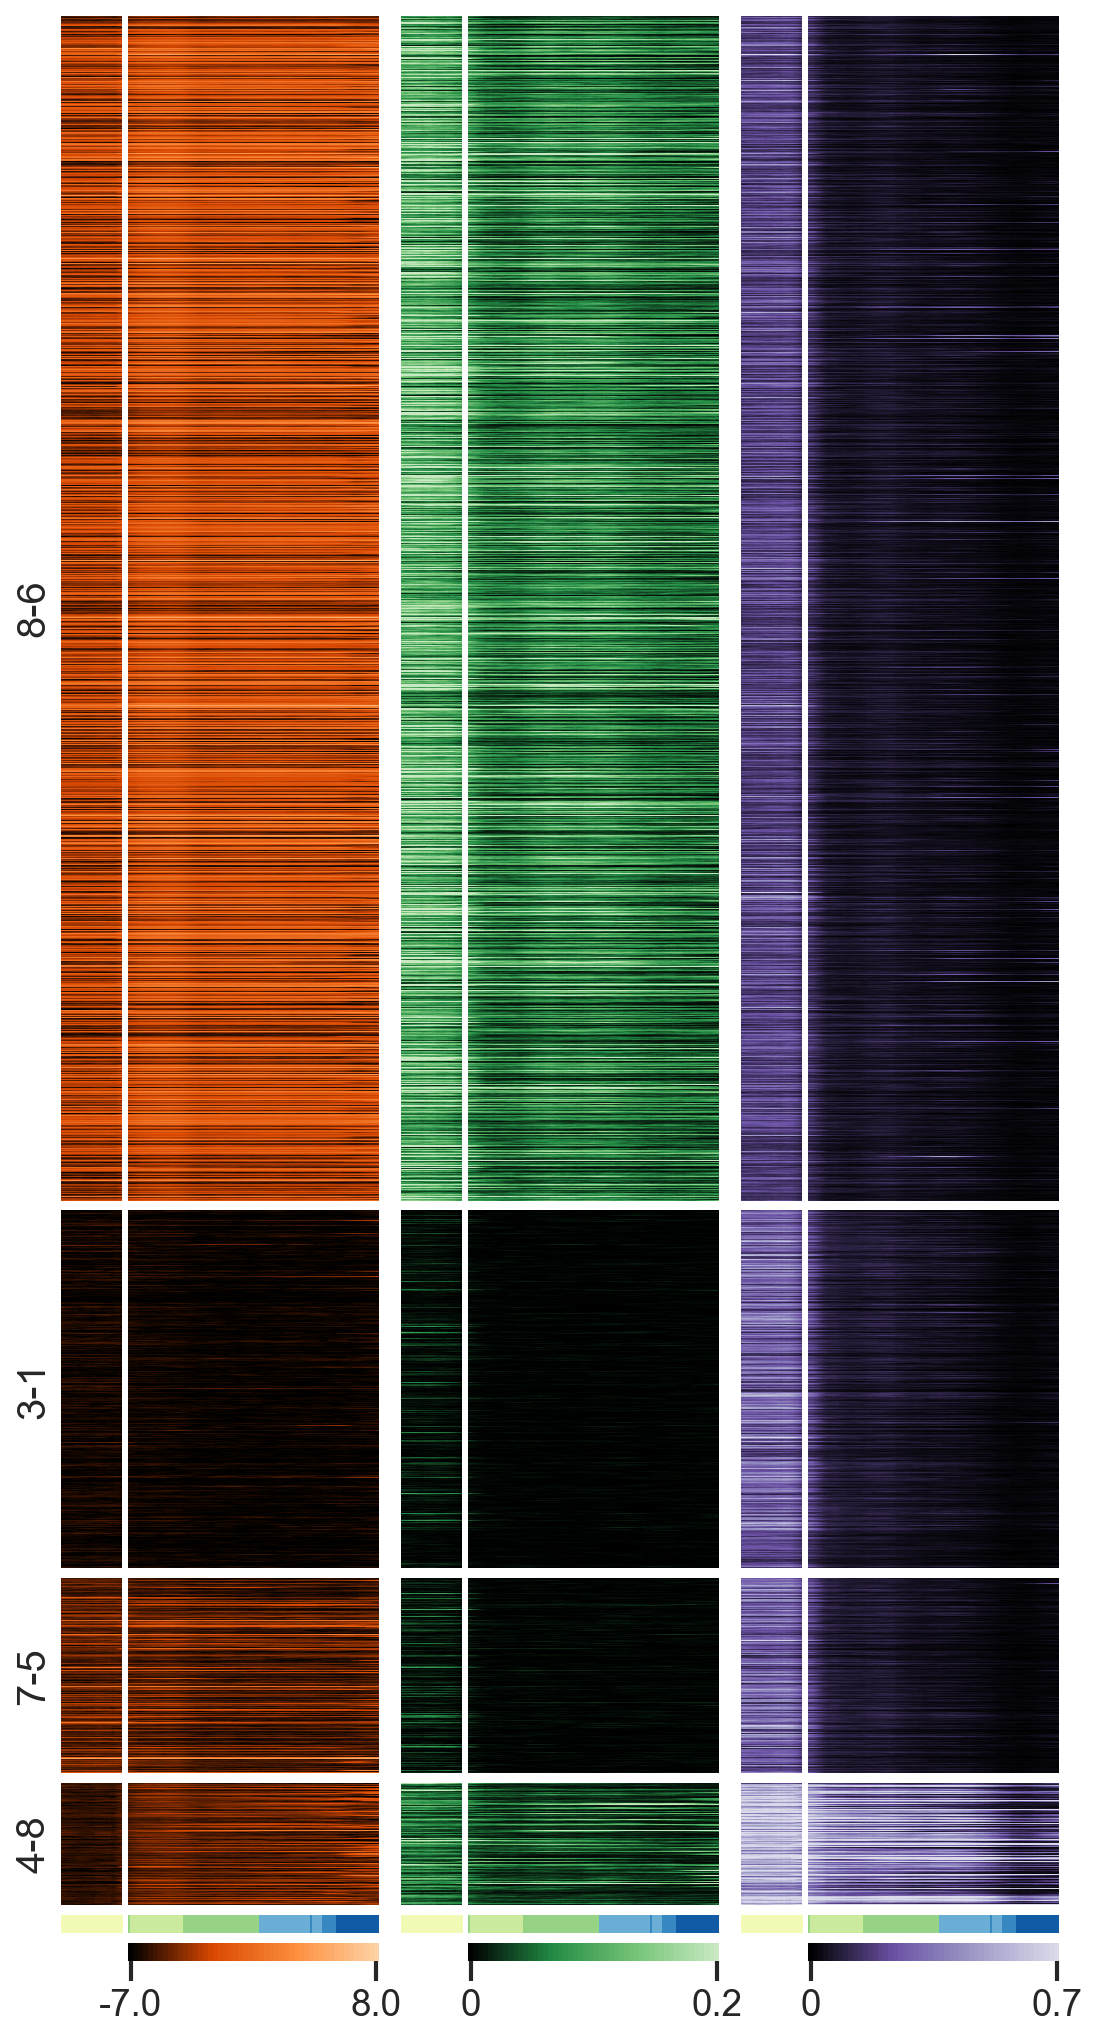

In [38]:
singlecellpseudotimeheatmap_log(lin='ect1', firststep=50, laststep=200, onlychanging=True, hightadjust=True, geneset=statetable['gene'].unique(), transitions=4)
#singlecellpseudotimeheatmap_log(lin='mes2', firststep=50, laststep=200, onlychanging=True, hightadjust=True, geneset=statetable['gene'].unique(), transitions=4)
#singlecellpseudotimeheatmap_log(lin='endo1', firststep=50, laststep=200, onlychanging=True, hightadjust=True, geneset=statetable['gene'].unique(), transitions=4)
singlecellpseudotimeheatmap_log(lin='ect1', firststep=10, laststep=60, onlychanging=True, hightadjust=True, geneset=statetable['gene'].unique(), transitions=4)


In [29]:

def ttest_transitions(firststep, laststep):

    Nsteps=9
    
    ttestresults=pd.DataFrame()
    
    for layer in all_pb_sn2_norm['layer'].unique():
    
        testset=all_pb_sn2_norm[((all_pb_sn2_norm['step']>=firststep)&(all_pb_sn2_norm['step']<=laststep)&(all_pb_sn2_norm['layer']==layer))].copy()
        
        result_RNA=pd.DataFrame()
        
        for target_group in all_pb_sn2_norm['lin'].unique():
            
            end=testset[testset['lin']==target_group]['step'].max()
            # Subset the data once
            
            test_data = testset[((testset['lin'] == target_group)&(testset['step']>(end-Nsteps))&(testset['step']<=end))]
            ref_data = testset[((testset['lin'] == target_group)&(testset['step']>=firststep)&(testset['step']<(firststep+Nsteps)))]
        
            # Extract matrices for all genes once
            test_matrix = test_data[['gene','step','counts']].pivot(index="gene", columns="step", values='counts').T.fillna(0)
            ref_matrix = ref_data[['gene','step','counts']].pivot(index="gene", columns="step", values='counts').T.fillna(0)
        
            # Precompute mean values for fold change calculation
            test_means = test_data[['gene','step','counts_log2']].pivot(index="gene", columns="step", values='counts_log2').T.fillna(0).mean(axis=0)
            ref_means = ref_data[['gene','step','counts_log2']].pivot(index="gene", columns="step", values='counts_log2').T.fillna(0).mean(axis=0)
            glob_mean = ((test_means+ref_means)/2).copy()
            glob_max = pd.concat([test_means,ref_means], axis=1).max(axis=1)
            
            # Calculate fold change (log2)
            fold_changes = test_means - ref_means
        
            # Perform t-tests in a vectorized way for each gene
            p_values = []
            t_stats = []
            
            for i in test_matrix.columns:  # Loop over genes by index
                var_test = np.var(test_matrix[i])
                var_ref = np.var(ref_matrix[i])
                if var_test < 1e-12 or var_ref < 1e-12:
                    # Variance is too low, skip the t-test
                    t_stat, p_val = np.nan, np.nan
                else:
                    t_stat, p_val = stats.ttest_ind(test_matrix.loc[:, i], ref_matrix.loc[:, i], equal_var=False)
            
                # Handle cases where t-test returns invalid p-values
                if np.isnan(p_val) or np.isinf(p_val) or p_val == 0:
                    p_val = 1  # Set to 1 for stability
                t_stats.append(t_stat)
                p_values.append(p_val)
        
            # Apply multiple testing correction (Benjamini-Hochberg FDR)
            corrected_pvals = multipletests(p_values, method='fdr_bh')[1]
        
            # Combine results into a DataFrame
            tmp2=statetable[((statetable['lin']==target_group)&(statetable['step']<=laststep)&(statetable['step']>=firststep))].copy()
            startstate=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1)).astype(int).astype(str)
            endstate=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1)).astype(int).astype(str)
            results = pd.DataFrame({
                'gene': test_matrix.columns,
                'fold': fold_changes,
                'mean':glob_mean,
                'max':glob_max,
                't_stat': t_stats,
                'p_value': p_values,
                'corrected_p_value': corrected_pvals,
                'lin':target_group,
                'transition':startstate+endstate
            })
            result_RNA=pd.concat([result_RNA, results], ignore_index=True)
            if layer=='RNA':
                result_RNA.loc[result_RNA['max']<-6,'corrected_p_value']=1
            if layer=='K4':
                result_RNA.loc[result_RNA['max']<-6,'corrected_p_value']=1
            if layer=='K27':
                result_RNA.loc[result_RNA['max']<-3.5,'corrected_p_value']=1

                
        result_RNA['-log10p']=-np.log10(result_RNA['corrected_p_value'])
        result_RNA['sig']='no'
        result_RNA.loc[((result_RNA['fold']>2)&(result_RNA['corrected_p_value']<0.005)),'sig']='up'
        result_RNA.loc[((result_RNA['fold']<-2)&(result_RNA['corrected_p_value']<0.005)),'sig']='down'
        
        results_RNA=result_RNA[['gene','lin','mean','max','fold','-log10p','sig','transition','corrected_p_value']].copy()
        results_RNA.loc[:,'firststep']=firststep
        results_RNA.loc[:,'laststep']=laststep
        results_RNA.loc[:,'layer']=layer
    
        ttestresults=pd.concat([ttestresults, results_RNA], ignore_index=True)
    return ttestresults

In [41]:
earlysteps=ttest_transitions(firststep=10, laststep=60)
latesteps=ttest_transitions(firststep=50, laststep=200)
longsteps=ttest_transitions(firststep=10, laststep=200)


In [42]:
earlysteps['mean_lin']=2 ** earlysteps['mean']
latesteps['mean_lin']=2 ** latesteps['mean']
longsteps['mean_lin']=2 ** longsteps['mean']

earlysteps['max_lin']=2 ** earlysteps['max']
latesteps['max_lin']=2 ** latesteps['max']
longsteps['max_lin']=2 ** longsteps['max']

In [43]:
def plotvulcan(df, layer, color):

    sns.set_context("talk", font_scale=1)
    sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
     'ytick.left': True, 'axes.edgecolor': 'black'})
    
    
    fig, axes = plt.subplots(3, 3, figsize=(9, 9), gridspec_kw={'hspace': 0.4, 'wspace': 0.4 })
    axes = axes.flatten()
    
    pointer=0
    for h in df['lin'].unique():
    
        sns.scatterplot(data=df[((df['lin']==h)&(df['layer']==layer))], ax=axes[pointer], s=20, linewidth=0.5, x='fold',y='-log10p', alpha=0.5,hue='sig', hue_order=['no','up','down'],palette=['Grey',color,'Black'], legend=False)
        
        labelneg=len(df[((df['lin']==h)&(df['sig']=='down')&(df['layer']==layer))])
        labelpos=len(df[((df['lin']==h)&(df['sig']=='up')&(df['layer']==layer))])
        labelnone=len(df[((df['lin']==h)&(df['sig']=='no')&(df['layer']==layer))])
        
        axes[pointer].annotate(str(labelneg), xy=(0, 1), xytext=(5, -5), textcoords="offset points" , xycoords="axes fraction", fontsize=18, ha='left', va='top', color='Black')
        axes[pointer].annotate(str(labelpos), xy=(1, 1), xytext=(-5, -5), textcoords="offset points" , xycoords="axes fraction", fontsize=18, ha='right', va='top', color=color)
        axes[pointer].set(xlabel='',
               ylabel='',
               title=h)
        axes[pointer].set_xlim(-((abs(latesteps.loc[latesteps['layer']==layer,'fold'])).max()*1.1), ((abs(latesteps.loc[latesteps['layer']==layer,'fold'])).max()*1.1))
        axes[pointer].set_ylim(-1, (abs(latesteps.loc[latesteps['layer']==layer,'-log10p']).max()*1.1))
        pointer=pointer+1
    
    filename=folder+'FigS5g_vulcanoplot_'+layer+'_'+str(df['firststep'].min())+'to'+str(df['laststep'].max())+'.png'
    plt.savefig(filename, dpi=300, format='png', bbox_inches='tight')
    plt.show()

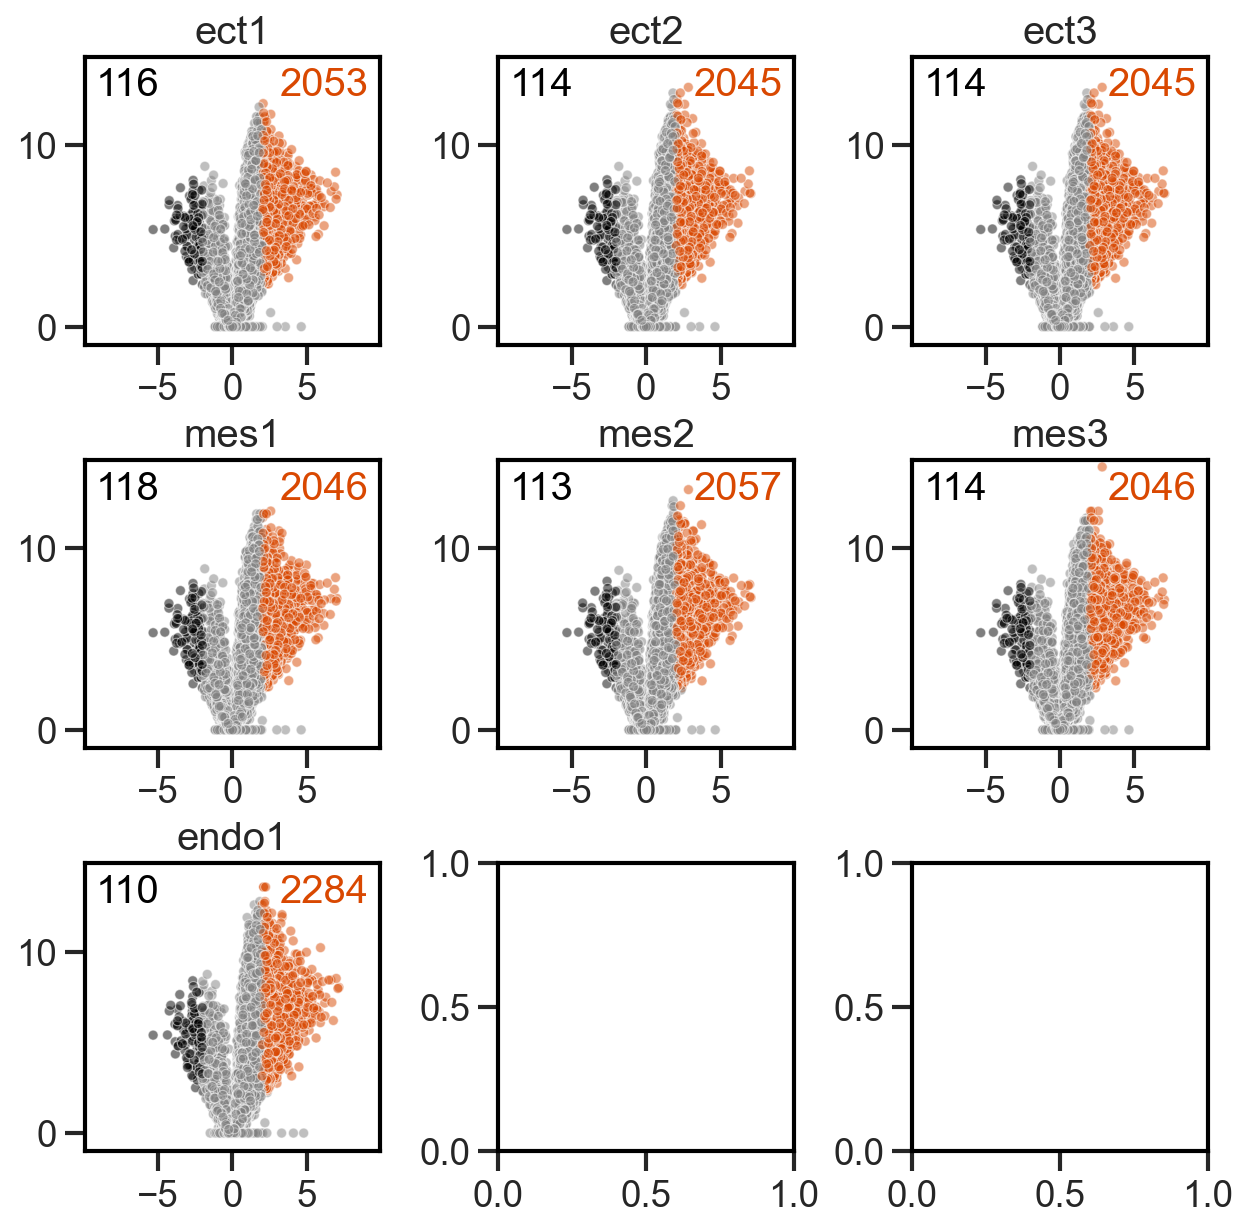

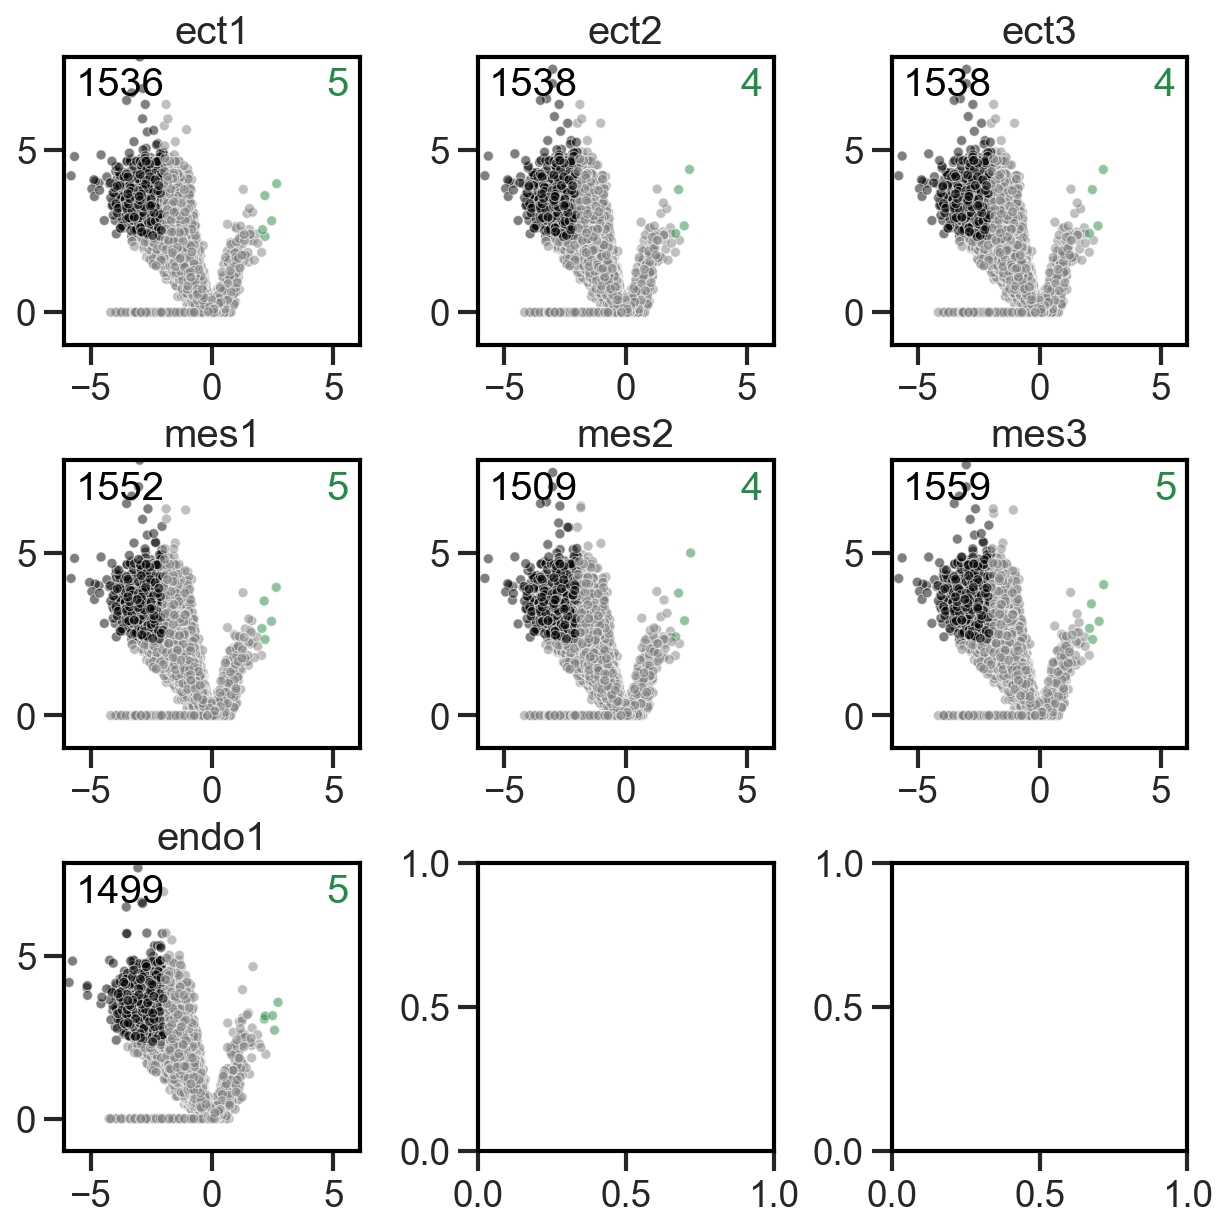

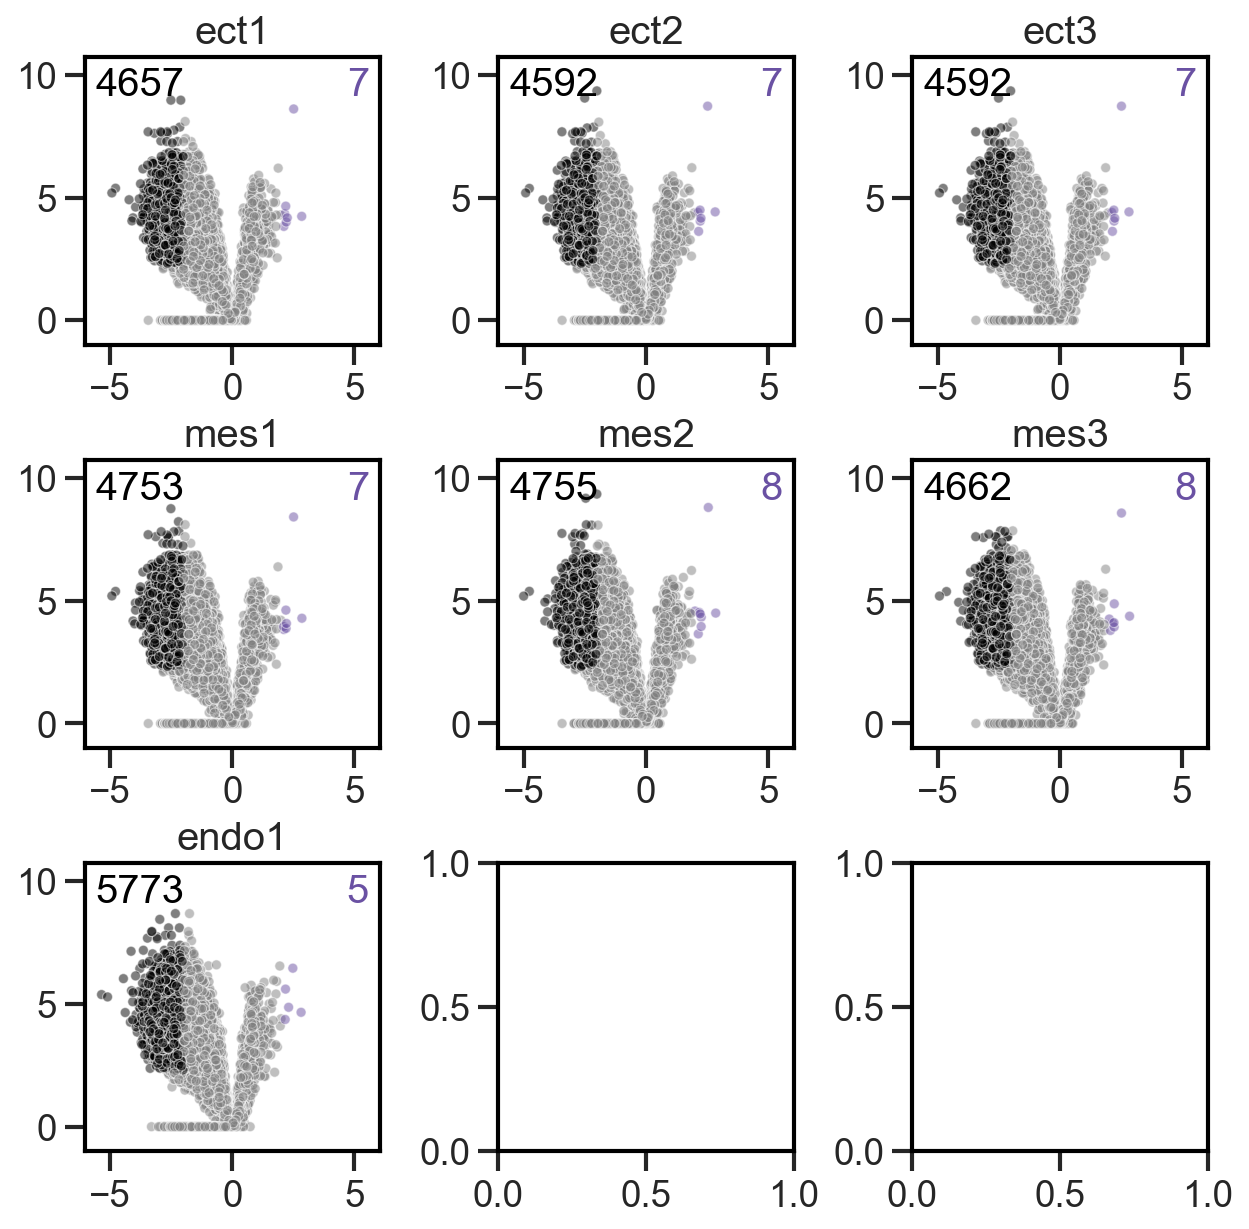

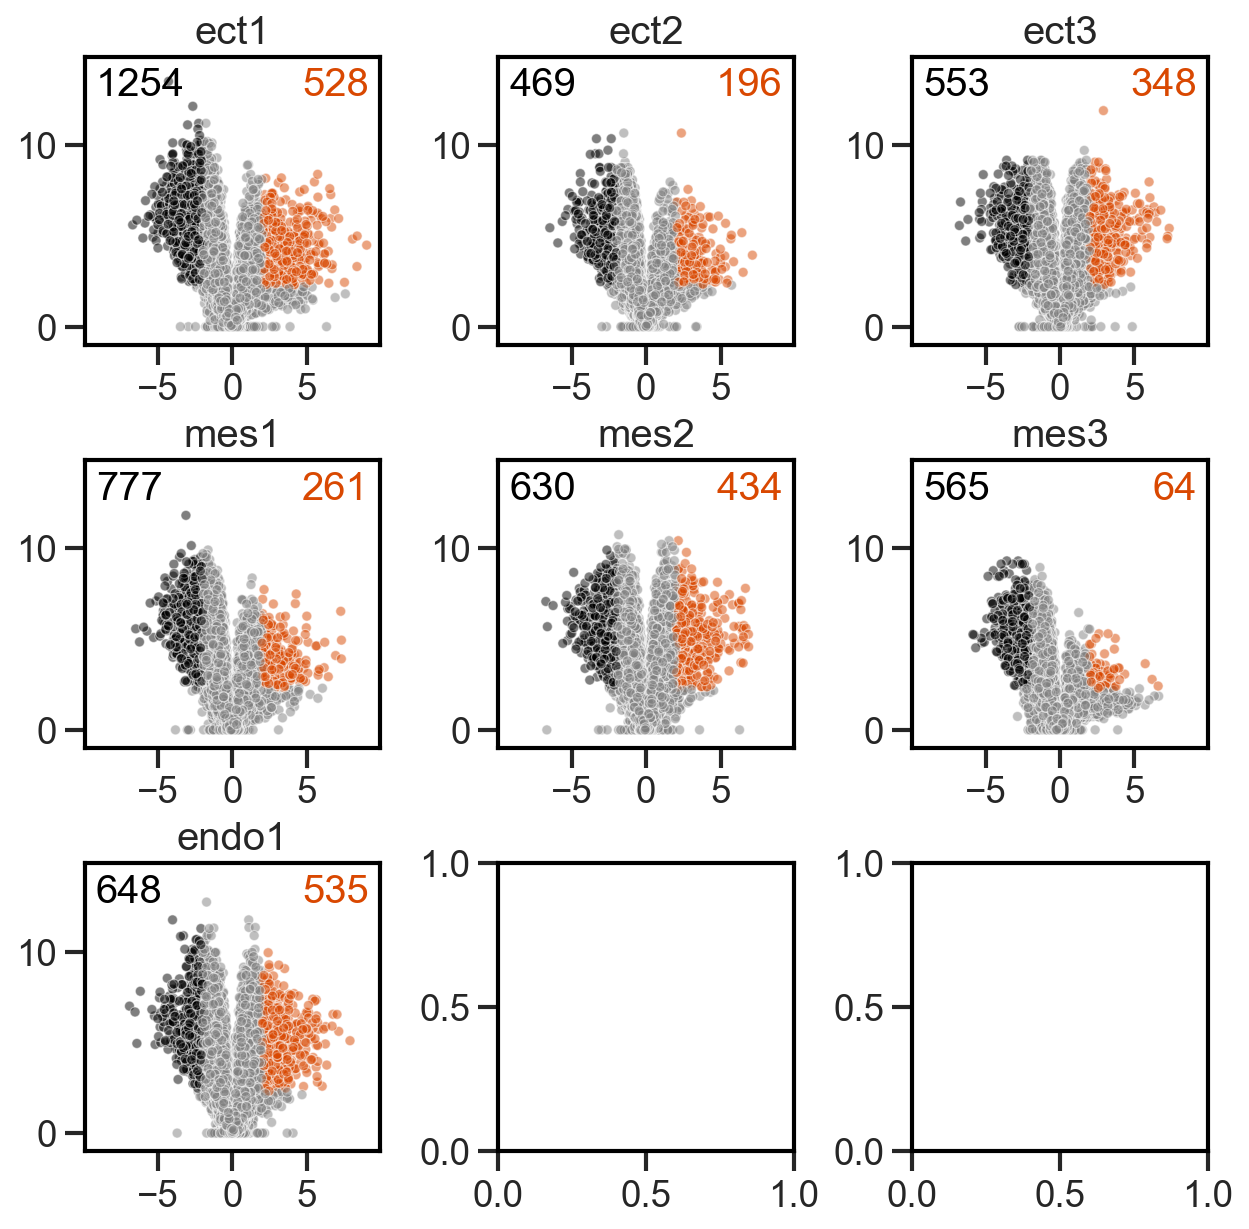

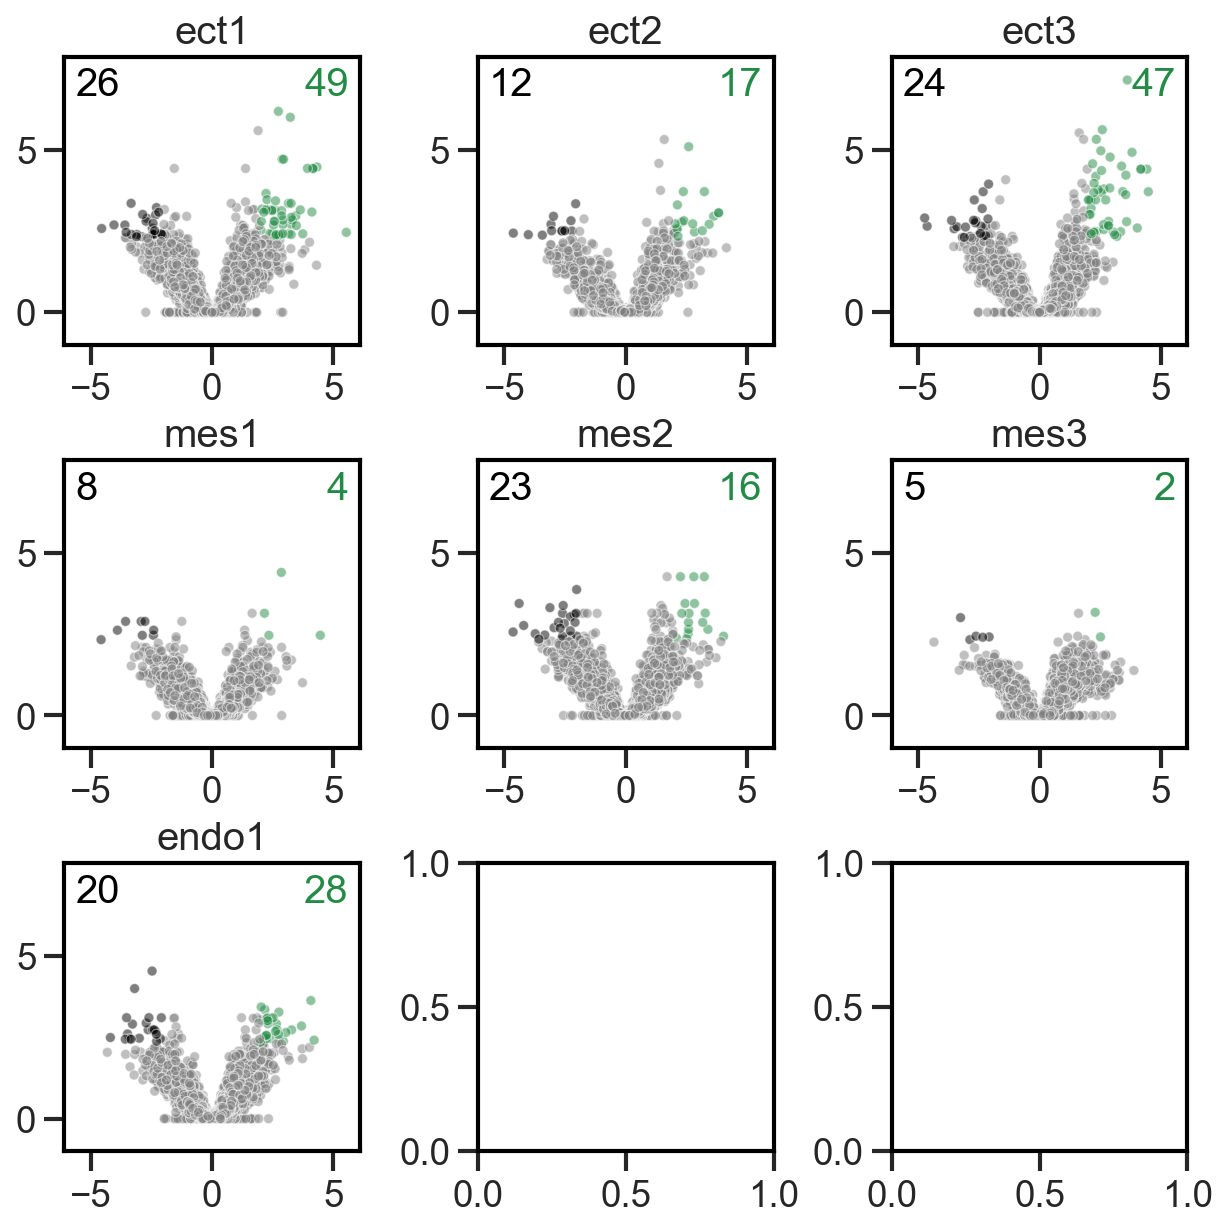

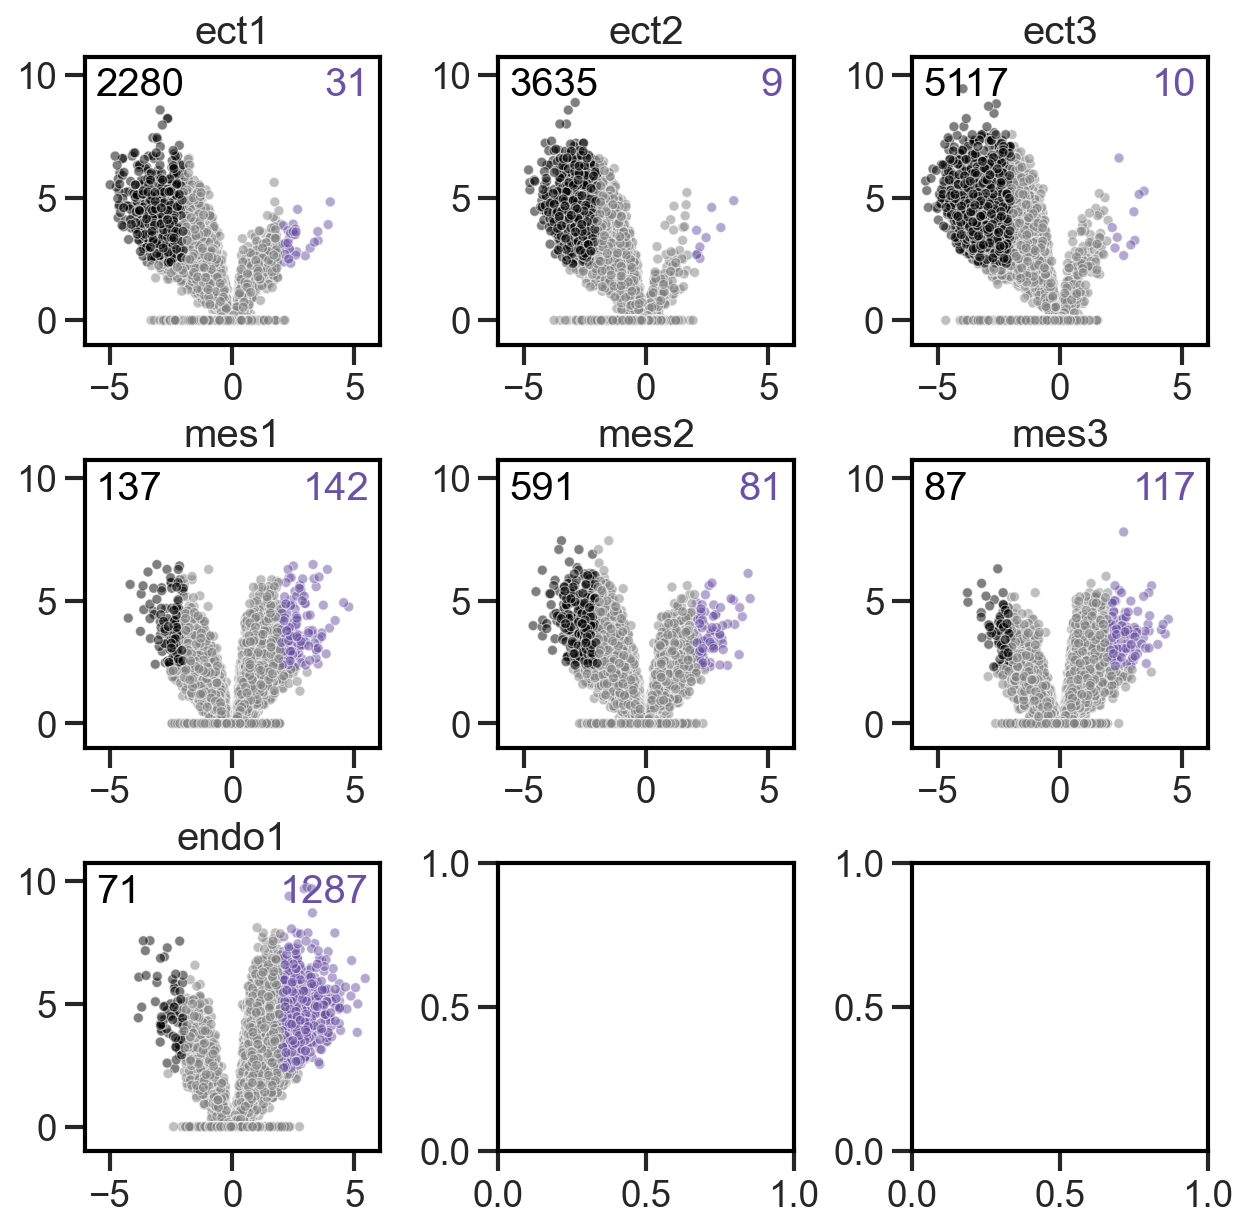

In [44]:
plotvulcan(earlysteps, 'RNA', Orange)
plotvulcan(earlysteps, 'K4', Green)
plotvulcan(earlysteps, 'K27', Purple)

plotvulcan(latesteps, 'RNA', Orange)
plotvulcan(latesteps, 'K4', Green)
plotvulcan(latesteps, 'K27', Purple)



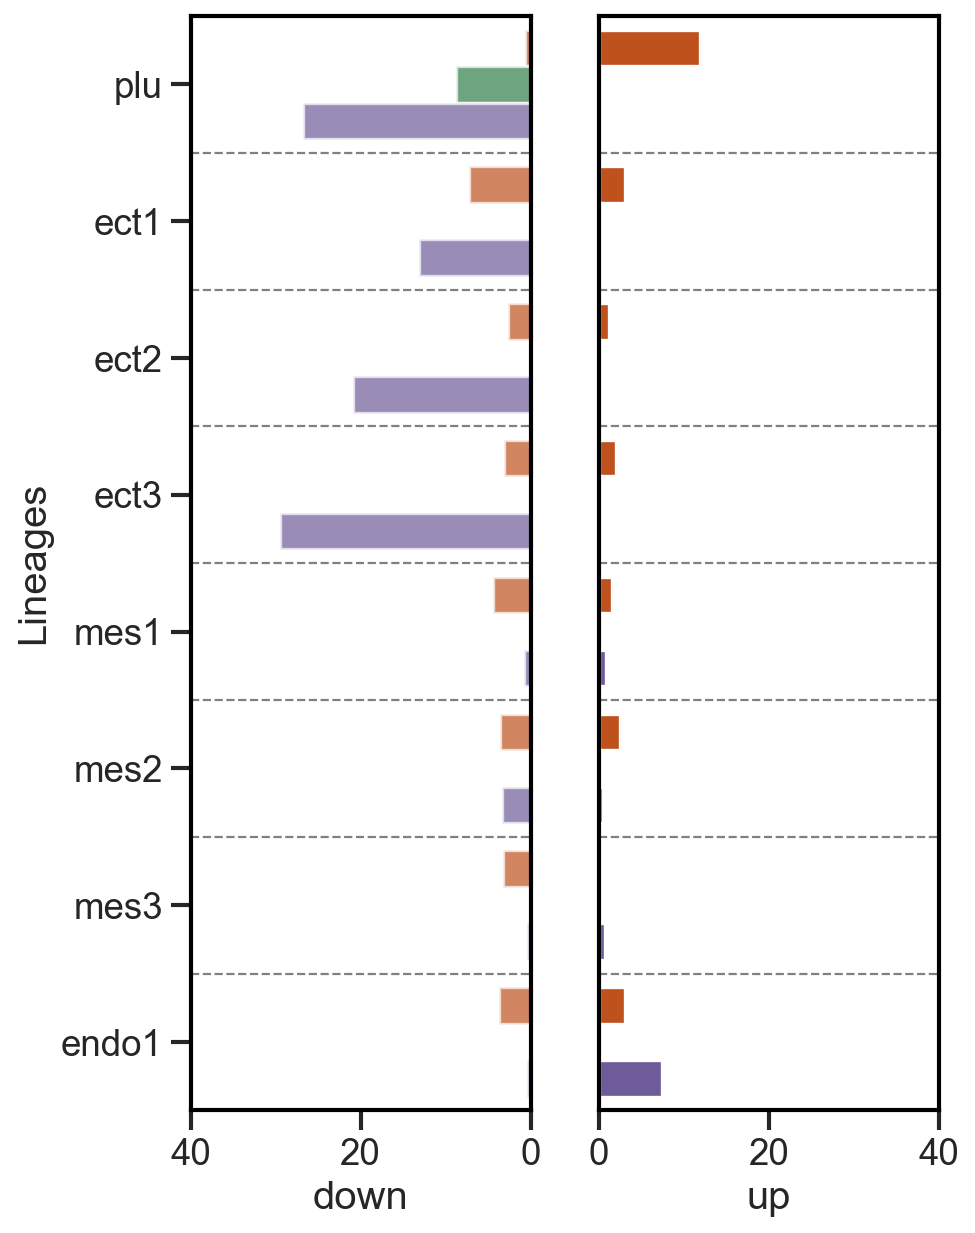

In [45]:
geneset=statetable['gene'].unique()

plotdata1=earlysteps[((earlysteps['lin']=='ect1')&(earlysteps['gene'].isin(geneset)))].groupby(['layer','lin','sig'])['gene'].count().reset_index()
plotdata1['lin']='plu'
plotdata2=latesteps[(latesteps['gene'].isin(geneset))].groupby(['layer','lin','sig'])['gene'].count().reset_index()
plotdata=pd.concat([plotdata1, plotdata2], ignore_index=True)
plotdata['fraction']=(plotdata['gene']/len(geneset))*100

fig, axes = plt.subplots(1, 2, figsize=(6, 9))
axes = axes.flatten()

sns.barplot(data=plotdata[((plotdata['sig']=='up')&(plotdata['sig']!='no'))], ax=axes[1],y='lin', x='fraction', order=['plu','ect1','ect2','ect3','mes1','mes2','mes3','endo1'], hue='layer', hue_order=['RNA','K4','K27'],palette=[Orange,Green,Purple])
axes[1].set_xlim(0,40)
for pos in range(1, len(earlysteps['lin'].unique())+1):
    axes[1].axhline(pos - 0.5, color="gray", linestyle="--", linewidth=1)
axes[1].get_legend().remove()
axes[1].tick_params(labelleft=False, left=False)
axes[1].set(xlabel='up', ylabel='', title='')

sns.barplot(data=plotdata[((plotdata['sig']=='down')&(plotdata['sig']!='no'))], ax=axes[0],alpha=0.7,y='lin', x='fraction', order=['plu','ect1','ect2','ect3','mes1','mes2','mes3','endo1'], hue='layer', hue_order=['RNA','K4','K27'],palette=[Orange,Green,Purple])
axes[0].set_xlim(40,0)
for pos in range(1, len(earlysteps['lin'].unique())+1):
    axes[0].axhline(pos - 0.5, color="gray", linestyle="--", linewidth=1)
axes[0].get_legend().remove()
axes[0].set(xlabel='down', ylabel='Lineages', title='')


filename=folder+'Fig5h_barplot_transitions_by_gerlayer_fraction.pdf'
plt.savefig(filename, dpi=300, format='pdf', bbox_inches='tight')
plt.show()

In [46]:
def sigchangebarplotearly_percent(lin, plotnumber, maxv, geneset=statetable['gene'].unique()):
    geneset=statetable['gene'].unique()
    transtoplot=earlysteps[((earlysteps['lin']==lin)&(earlysteps['layer']=='RNA')&(earlysteps['gene'].isin(geneset)))].groupby(['transition'])['gene'].count().sort_values(ascending=False)[:plotnumber].index
    plotdata=earlysteps[((earlysteps['lin']==lin)&(earlysteps['gene'].isin(geneset)))].groupby(['layer','transition','sig'])['gene'].count().reset_index()
    plotdata.columns=['layer','transition','sig','count']
    plotdata.columns=['layer','transition','sig','count']
    groupsize=earlysteps[((earlysteps['lin']==lin)&(earlysteps['gene'].isin(geneset))&(earlysteps['layer']=='RNA'))].groupby(['transition'])['gene'].count().reset_index()
    groupsize.columns=['transition','size']
    plotdata=plotdata.merge(groupsize, how='left', left_on=['transition'],right_on=['transition'])
    plotdata['fraction']=(plotdata['count']/plotdata['size'])*100
    
    fig, axes = plt.subplots(1, 2, figsize=(4, 9))
    axes = axes.flatten()
    
    sns.barplot(data=plotdata[((plotdata['sig']=='up')&(plotdata['sig']!='no'))], ax=axes[1],y='transition', x='fraction', hue='layer', order=transtoplot,hue_order=['RNA','K4','K27'],palette=[Orange,Green,Purple])
    axes[1].set_xlim(0,maxv)
    for pos in range(1, plotnumber):
        axes[1].axhline(pos - 0.5, color="gray", linestyle="--", linewidth=1)
    axes[1].get_legend().remove()
    axes[1].tick_params(labelleft=False, left=False)
    axes[1].set(xlabel='up', ylabel='', title='')
    
    sns.barplot(data=plotdata[((plotdata['sig']=='down')&(plotdata['sig']!='no'))], ax=axes[0],alpha=0.7,y='transition', x='fraction', hue='layer', order=transtoplot, hue_order=['RNA','K4','K27'],palette=[Orange,Green,Purple])
    axes[0].set_xlim(maxv,0)
    for pos in range(1, plotnumber):
        axes[0].axhline(pos - 0.5, color="gray", linestyle="--", linewidth=1)
    axes[0].get_legend().remove()
    axes[0].set(xlabel='down', ylabel='transitions', title=lin)
    
    filename=folder+'FigS5g_barplot_early_fraction'+lin+'_transitions_'+str(plotnumber)+'.pdf'
    plt.savefig(filename, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

In [47]:
def sigchangebarplotlate_percent(lin, plotnumber,maxv, geneset=statetable['gene'].unique()):
    geneset=statetable['gene'].unique()
    transtoplot=latesteps[((latesteps['lin']==lin)&(latesteps['layer']=='RNA')&(latesteps['gene'].isin(geneset)))].groupby(['transition'])['gene'].count().sort_values(ascending=False)[:plotnumber].index
    plotdata=latesteps[((latesteps['lin']==lin)&(latesteps['gene'].isin(geneset)))].groupby(['layer','transition','sig'])['gene'].count().reset_index()
    plotdata.columns=['layer','transition','sig','count']
    plotdata.columns=['layer','transition','sig','count']
    groupsize=latesteps[((latesteps['lin']==lin)&(latesteps['gene'].isin(geneset))&(latesteps['layer']=='RNA'))].groupby(['transition'])['gene'].count().reset_index()
    groupsize.columns=['transition','size']
    plotdata=plotdata.merge(groupsize, how='left', left_on=['transition'],right_on=['transition'])
    plotdata['fraction']=(plotdata['count']/plotdata['size'])*100
    
    fig, axes = plt.subplots(1, 2, figsize=(4, 9))
    axes = axes.flatten()
    
    sns.barplot(data=plotdata[((plotdata['sig']=='up')&(plotdata['sig']!='no'))], ax=axes[1],y='transition', x='fraction', hue='layer', order=transtoplot,hue_order=['RNA','K4','K27'],palette=[Orange,Green,Purple])
    axes[1].set_xlim(0,maxv)
    for pos in range(1, plotnumber):
        axes[1].axhline(pos - 0.5, color="gray", linestyle="--", linewidth=1)
    axes[1].get_legend().remove()
    axes[1].tick_params(labelleft=False, left=False)
    axes[1].set(xlabel='up', ylabel='', title='')
    
    sns.barplot(data=plotdata[((plotdata['sig']=='down')&(plotdata['sig']!='no'))], ax=axes[0],alpha=0.7,y='transition', x='fraction', hue='layer', order=transtoplot, hue_order=['RNA','K4','K27'],palette=[Orange,Green,Purple])
    axes[0].set_xlim(maxv,0)
    for pos in range(1, plotnumber):
        axes[0].axhline(pos - 0.5, color="gray", linestyle="--", linewidth=1)
    axes[0].get_legend().remove()
    axes[0].set(xlabel='down', ylabel='transitions', title=lin)
    
    filename=folder+'FigS5g_barplot_late_fraction'+lin+'_transitions_'+str(plotnumber)+'.pdf'
    plt.savefig(filename, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

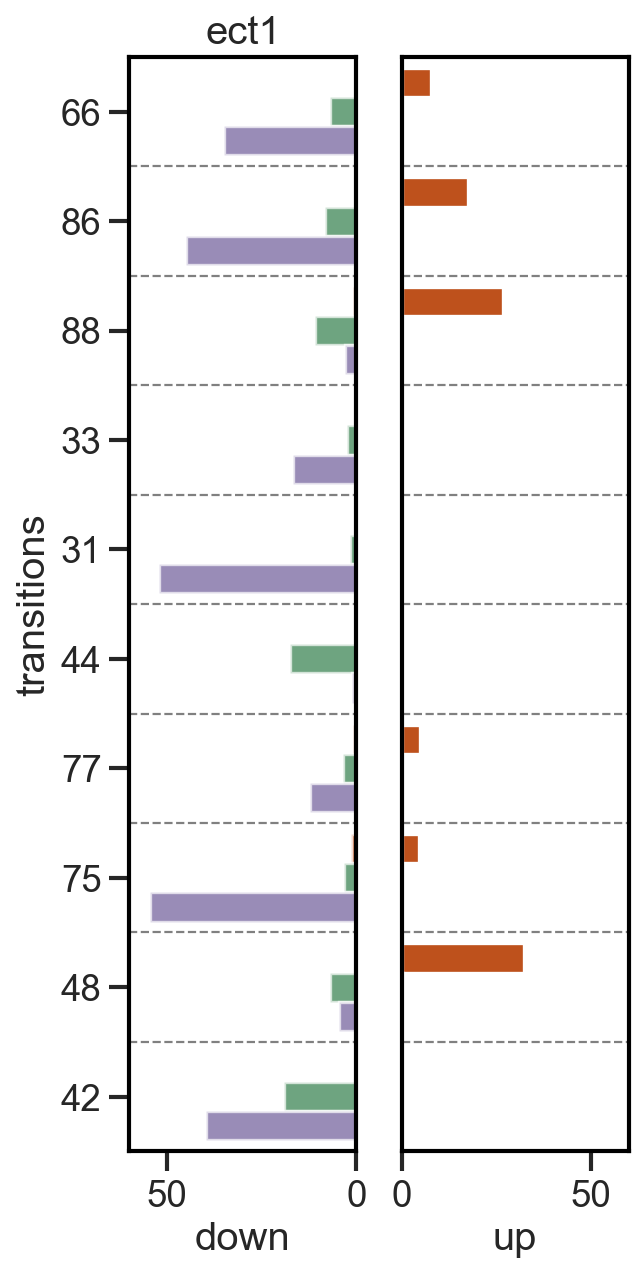

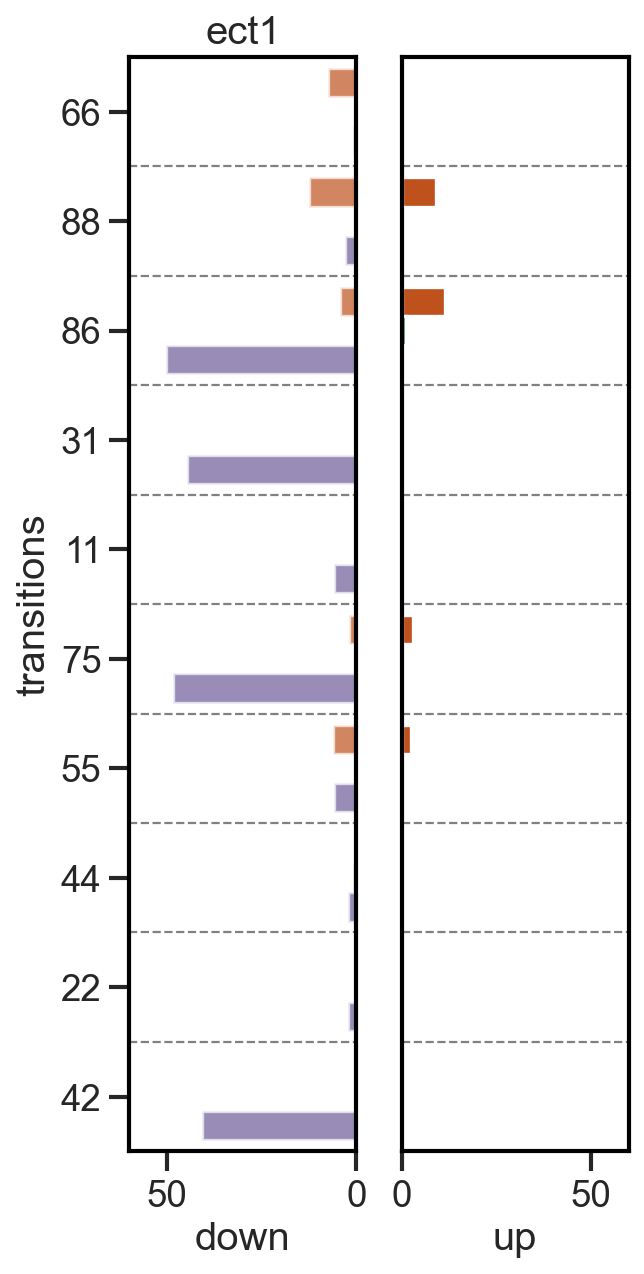

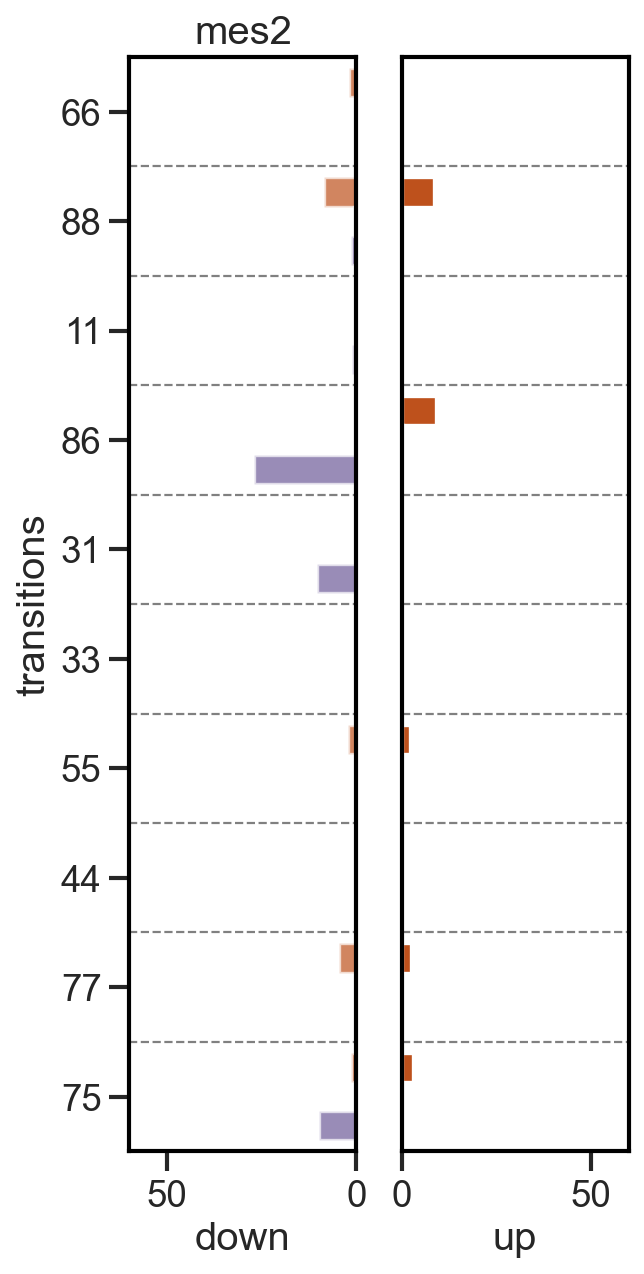

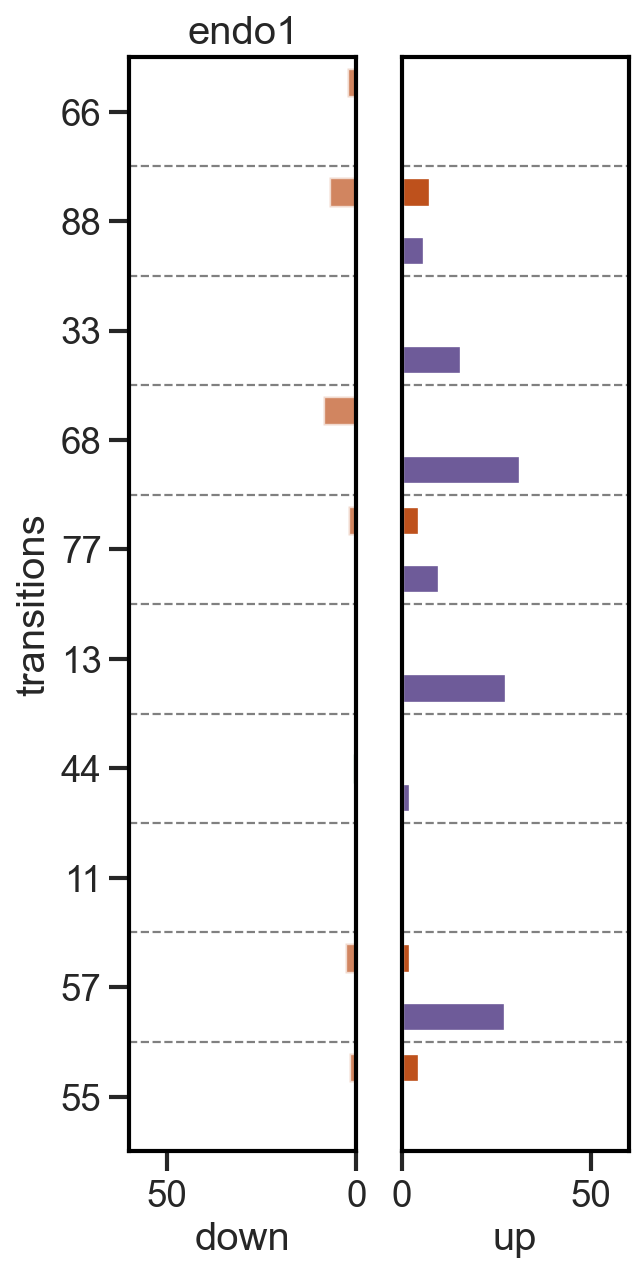

In [48]:
sigchangebarplotearly_percent(lin='ect1', plotnumber=10, geneset=statetable['gene'].unique(),maxv=60)
sigchangebarplotlate_percent(lin='ect1', plotnumber=10, geneset=statetable['gene'].unique(),maxv=60)
sigchangebarplotlate_percent(lin='mes2', plotnumber=10, geneset=statetable['gene'].unique(),maxv=60)
sigchangebarplotlate_percent(lin='endo1', plotnumber=10, geneset=statetable['gene'].unique(),maxv=60)


In [50]:
expr_genes=all_pb_sn2_norm.loc[((all_pb_sn2_norm['layer']=='RNA')&(all_pb_sn2_norm[version]==1)),'gene'].unique()

Pset=pd.read_csv('input/20250310_diff_genes_ESCvsP.csv', sep = ',', index_col=0)
Pset=Pset[((Pset['padj']<0.005)&(Pset['log2FoldChange']>2)&(Pset.index.isin(expr_genes)))].index

Mset=pd.read_csv('input/20250310_diff_genes_PvsMES.csv', sep = ',', index_col=0)
Mset=Mset[((Mset['padj']<0.005)&(Mset['log2FoldChange']>2)&(Mset.index.isin(expr_genes)))].index

ECTset=pd.read_csv('input/20250310_diff_genes_PvsECT.csv', sep = ',', index_col=0)
ECTset=ECTset[((ECTset['padj']<0.005)&(ECTset['log2FoldChange']>2)&(ECTset.index.isin(expr_genes)))].index

ENDset=pd.read_csv('input/20250310_diff_genes_PvsEND.csv', sep = ',', index_col=0)
ENDset=ENDset[((ENDset['padj']<0.005)&(ENDset['log2FoldChange']>2)&(ENDset.index.isin(expr_genes)))].index




In [51]:
#plot transition matrix for all genes, start, end can be slected, end ESC 40, end pluri 70
def transitiondotplot2(name, geneset=statetable['gene'].unique(), onlychanging=False, huemax=100, sizemax=6000):

    fig, axes = plt.subplots(3, 3, figsize=(15, 15), gridspec_kw={'hspace': 0.3, 'wspace': 0.3, 'height_ratios':(5,5,5)})
    

    axes = axes.flatten()

    
    
    firststep=1
    laststep=60
    tmp1=statetable[((statetable['step']<=laststep)&(statetable['gene'].isin(geneset)))].copy()
    
    linage='ect1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      
    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start', hue='fraction',edgecolor='gray',linewidth=1, ax=axes[0], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[0].set(xlabel='',
       ylabel='',
       title='Plu')
    
    sns.heatmap(emptydata, ax=axes[1], cbar=False, annot=False, linewidths=0, linecolor="white")
    axes[1].tick_params(labelleft=False, left=False)
    axes[1].tick_params(labelbottom=False, bottom=False)
    axes[1].set(xlabel='',
           ylabel='',
           title='')
    
    firststep=50
    laststep=200
    tmp1=statetable[((statetable['step']<=laststep)&(statetable['gene'].isin(geneset)))].copy()
    
    linage='endo1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[2], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis')
    axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    axes[2].set(xlabel='',
       ylabel='',
       title='End1')
    
    
    linage='mes1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[3], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[3].set(xlabel='',
       ylabel='',
       title='Mes1')
    
    linage='mes2'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[4], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[4].set(xlabel='',
       ylabel='',
       title='Mes2')
    
    linage='mes3'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[5], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[5].set(xlabel='',
       ylabel='',
       title='Mes3')
    
    
    linage='ect1'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[6], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[6].set(xlabel='',
       ylabel='',
       title='Ect1')
    
    
    
    linage='ect2'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[7], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[7].set(xlabel='',
       ylabel='',
       title='Ect2')
    
    linage='ect3'
    tmp2=tmp1[((tmp1['lin']==linage))].copy()
    startset=np.round(tmp2.loc[((tmp2['step']>=firststep)&(tmp2['step']<firststep+9)),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    endset=np.round(tmp2.loc[((tmp2['step']>tmp2['step'].max()-9)&(tmp2['step']<=tmp2['step'].max())),['gene','step','full_state']].pivot(index="gene", columns="step", values='full_state').median(axis=1))
    
    plot1=pd.DataFrame(columns=['start','end','fraction','number'])
    for start in range(0,8):
        for end in range(0,8):
            
            tmp3=startset[startset==start+1].index
            changing=endset[((endset==end+1)&(endset.index.isin(tmp3)))].count()
            fraction=round((changing/(len(tmp3)+1))*100)
            results = pd.DataFrame({
                'start': [start+1],
                'end': [end+1],
                'fraction': [fraction],
                'number': [changing],
            })
            plot1=pd.concat([plot1, results], ignore_index=True)      

    if onlychanging==True:
        plot1.loc[(plot1['start']==plot1['end']),['fraction','number']]=0
    ax=sns.scatterplot(data=plot1, x='end', y='start',edgecolor='gray',linewidth=1, hue='fraction', ax=axes[8], hue_norm=(0, huemax), size_norm=(0, sizemax), size='number', sizes=(0, 600), palette='viridis', legend=False)
    axes[8].set(xlabel='',
       ylabel='',
       title='Ect3')
    
    
    
    
    filename=folder+'FigS6b_transitionmatrix_'+name+str(onlychanging)+'.pdf'
    plt.savefig(filename, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


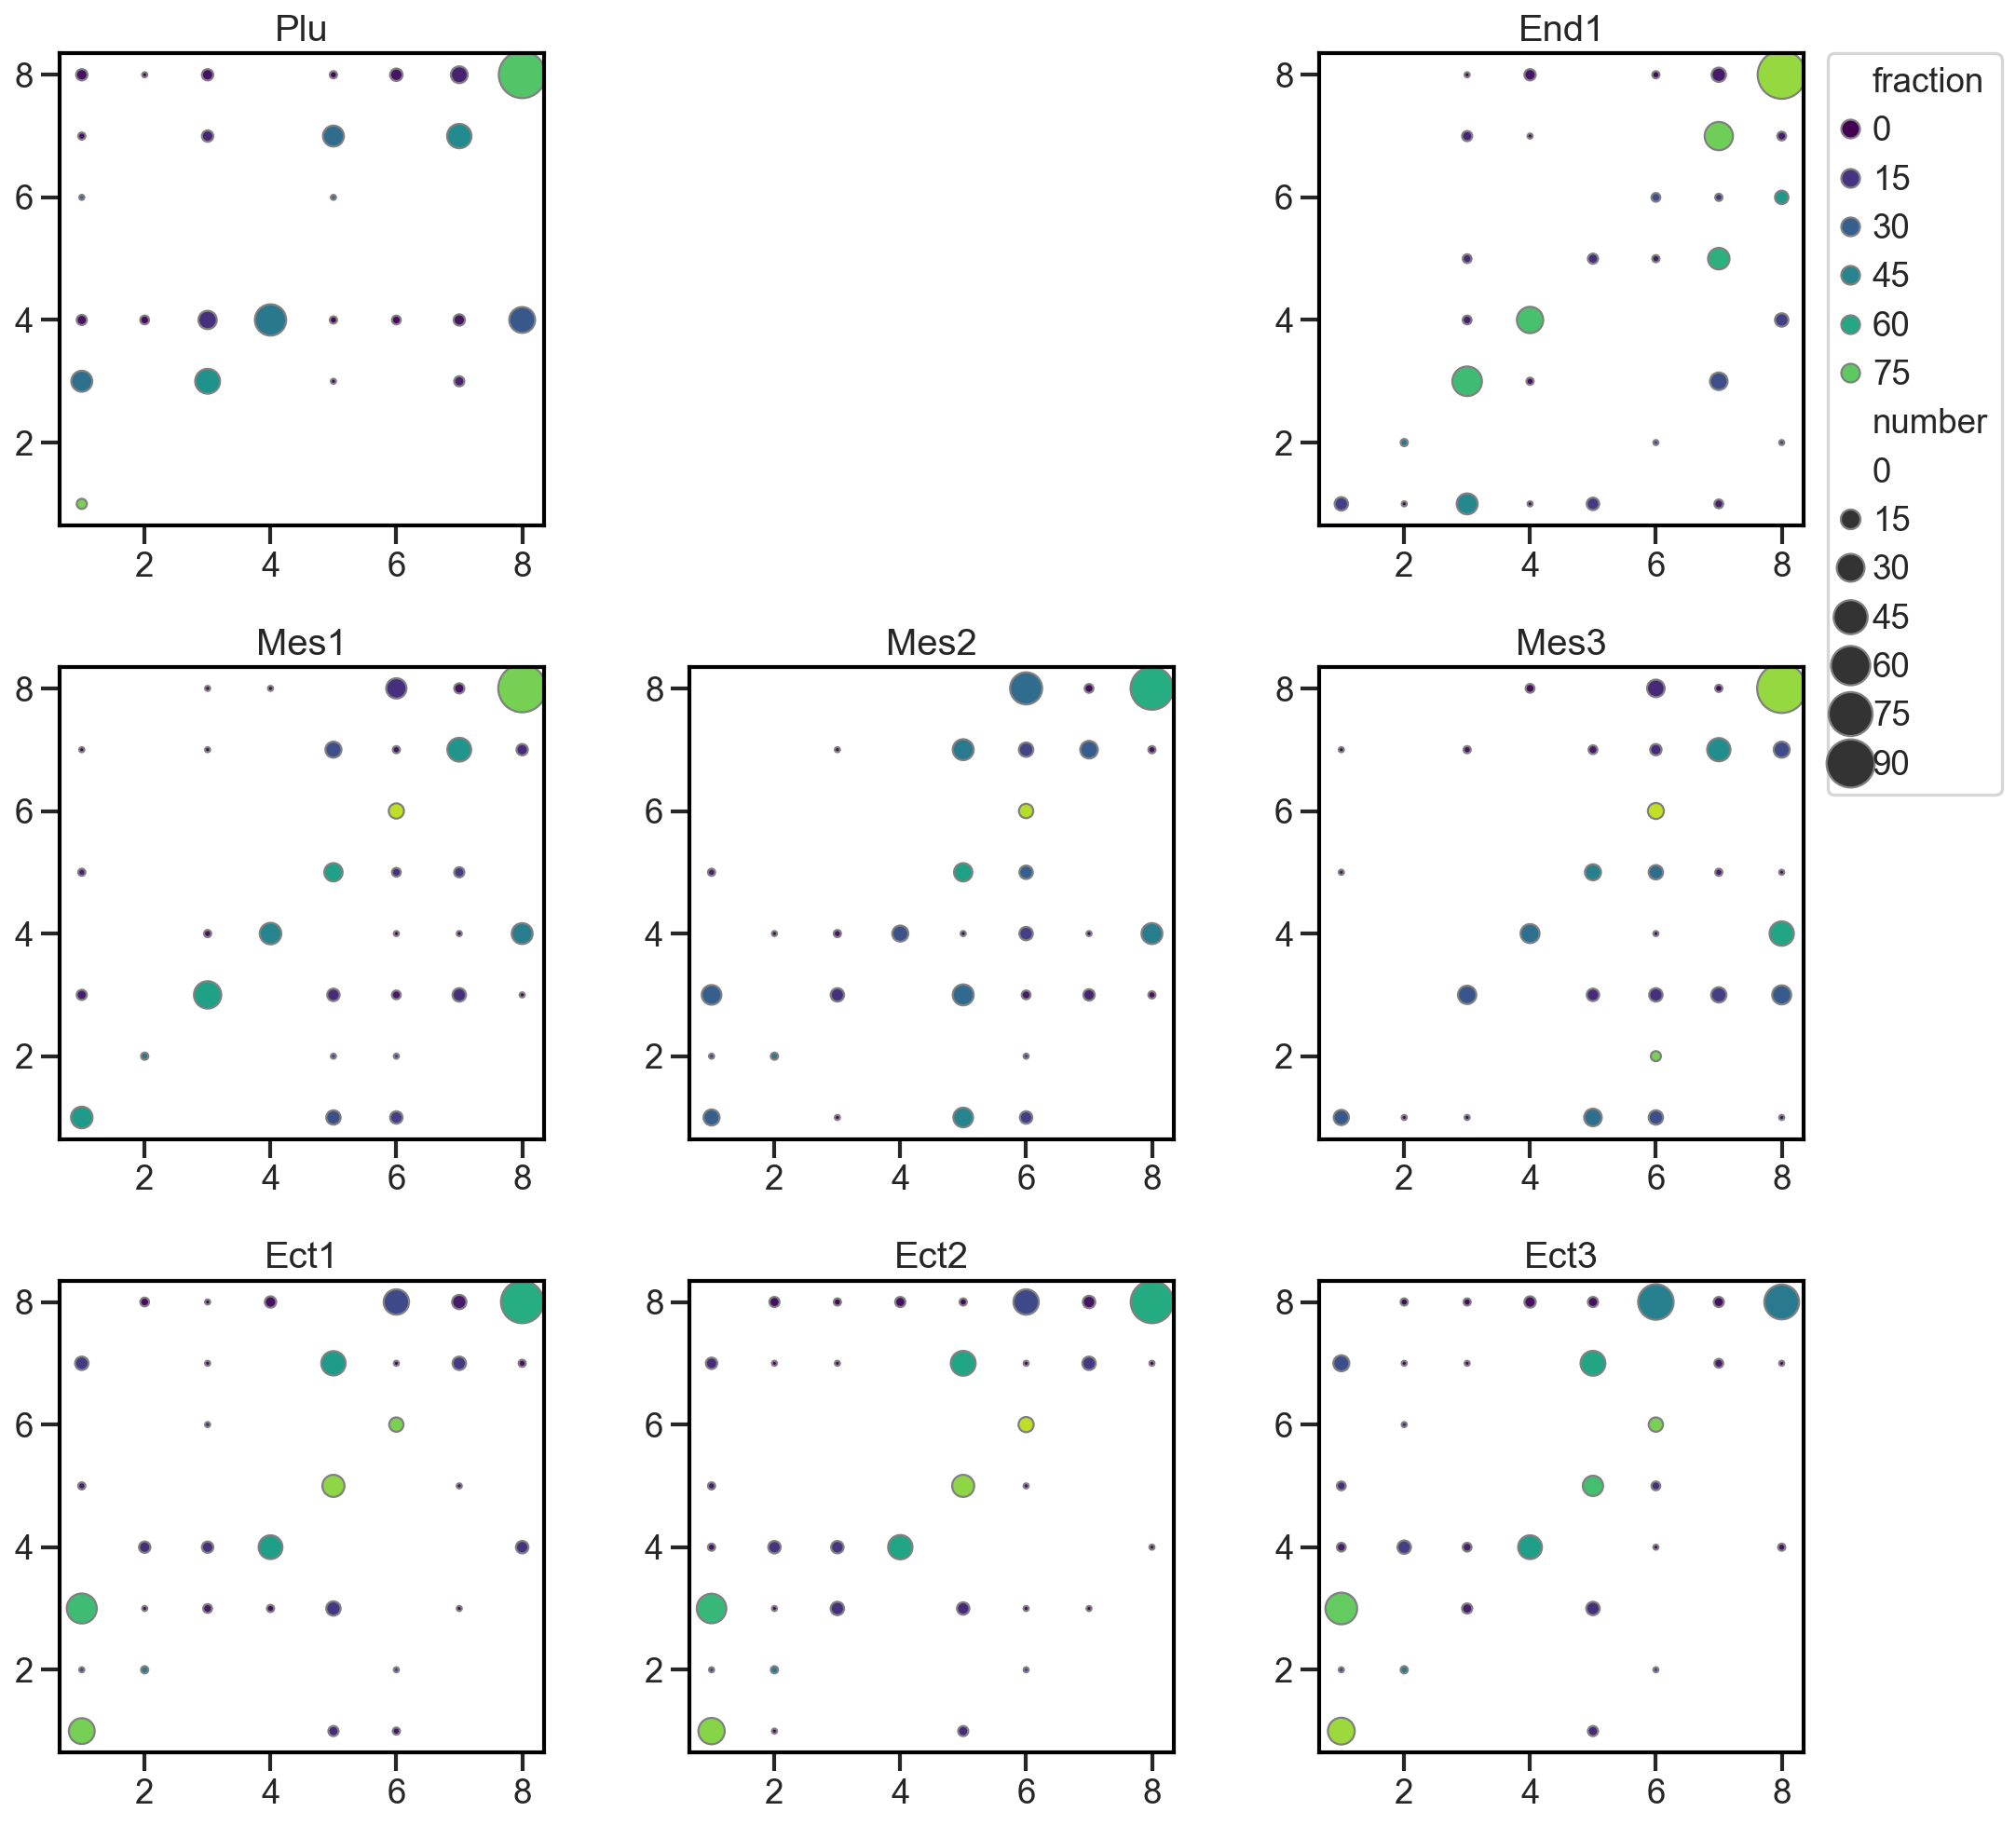

C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


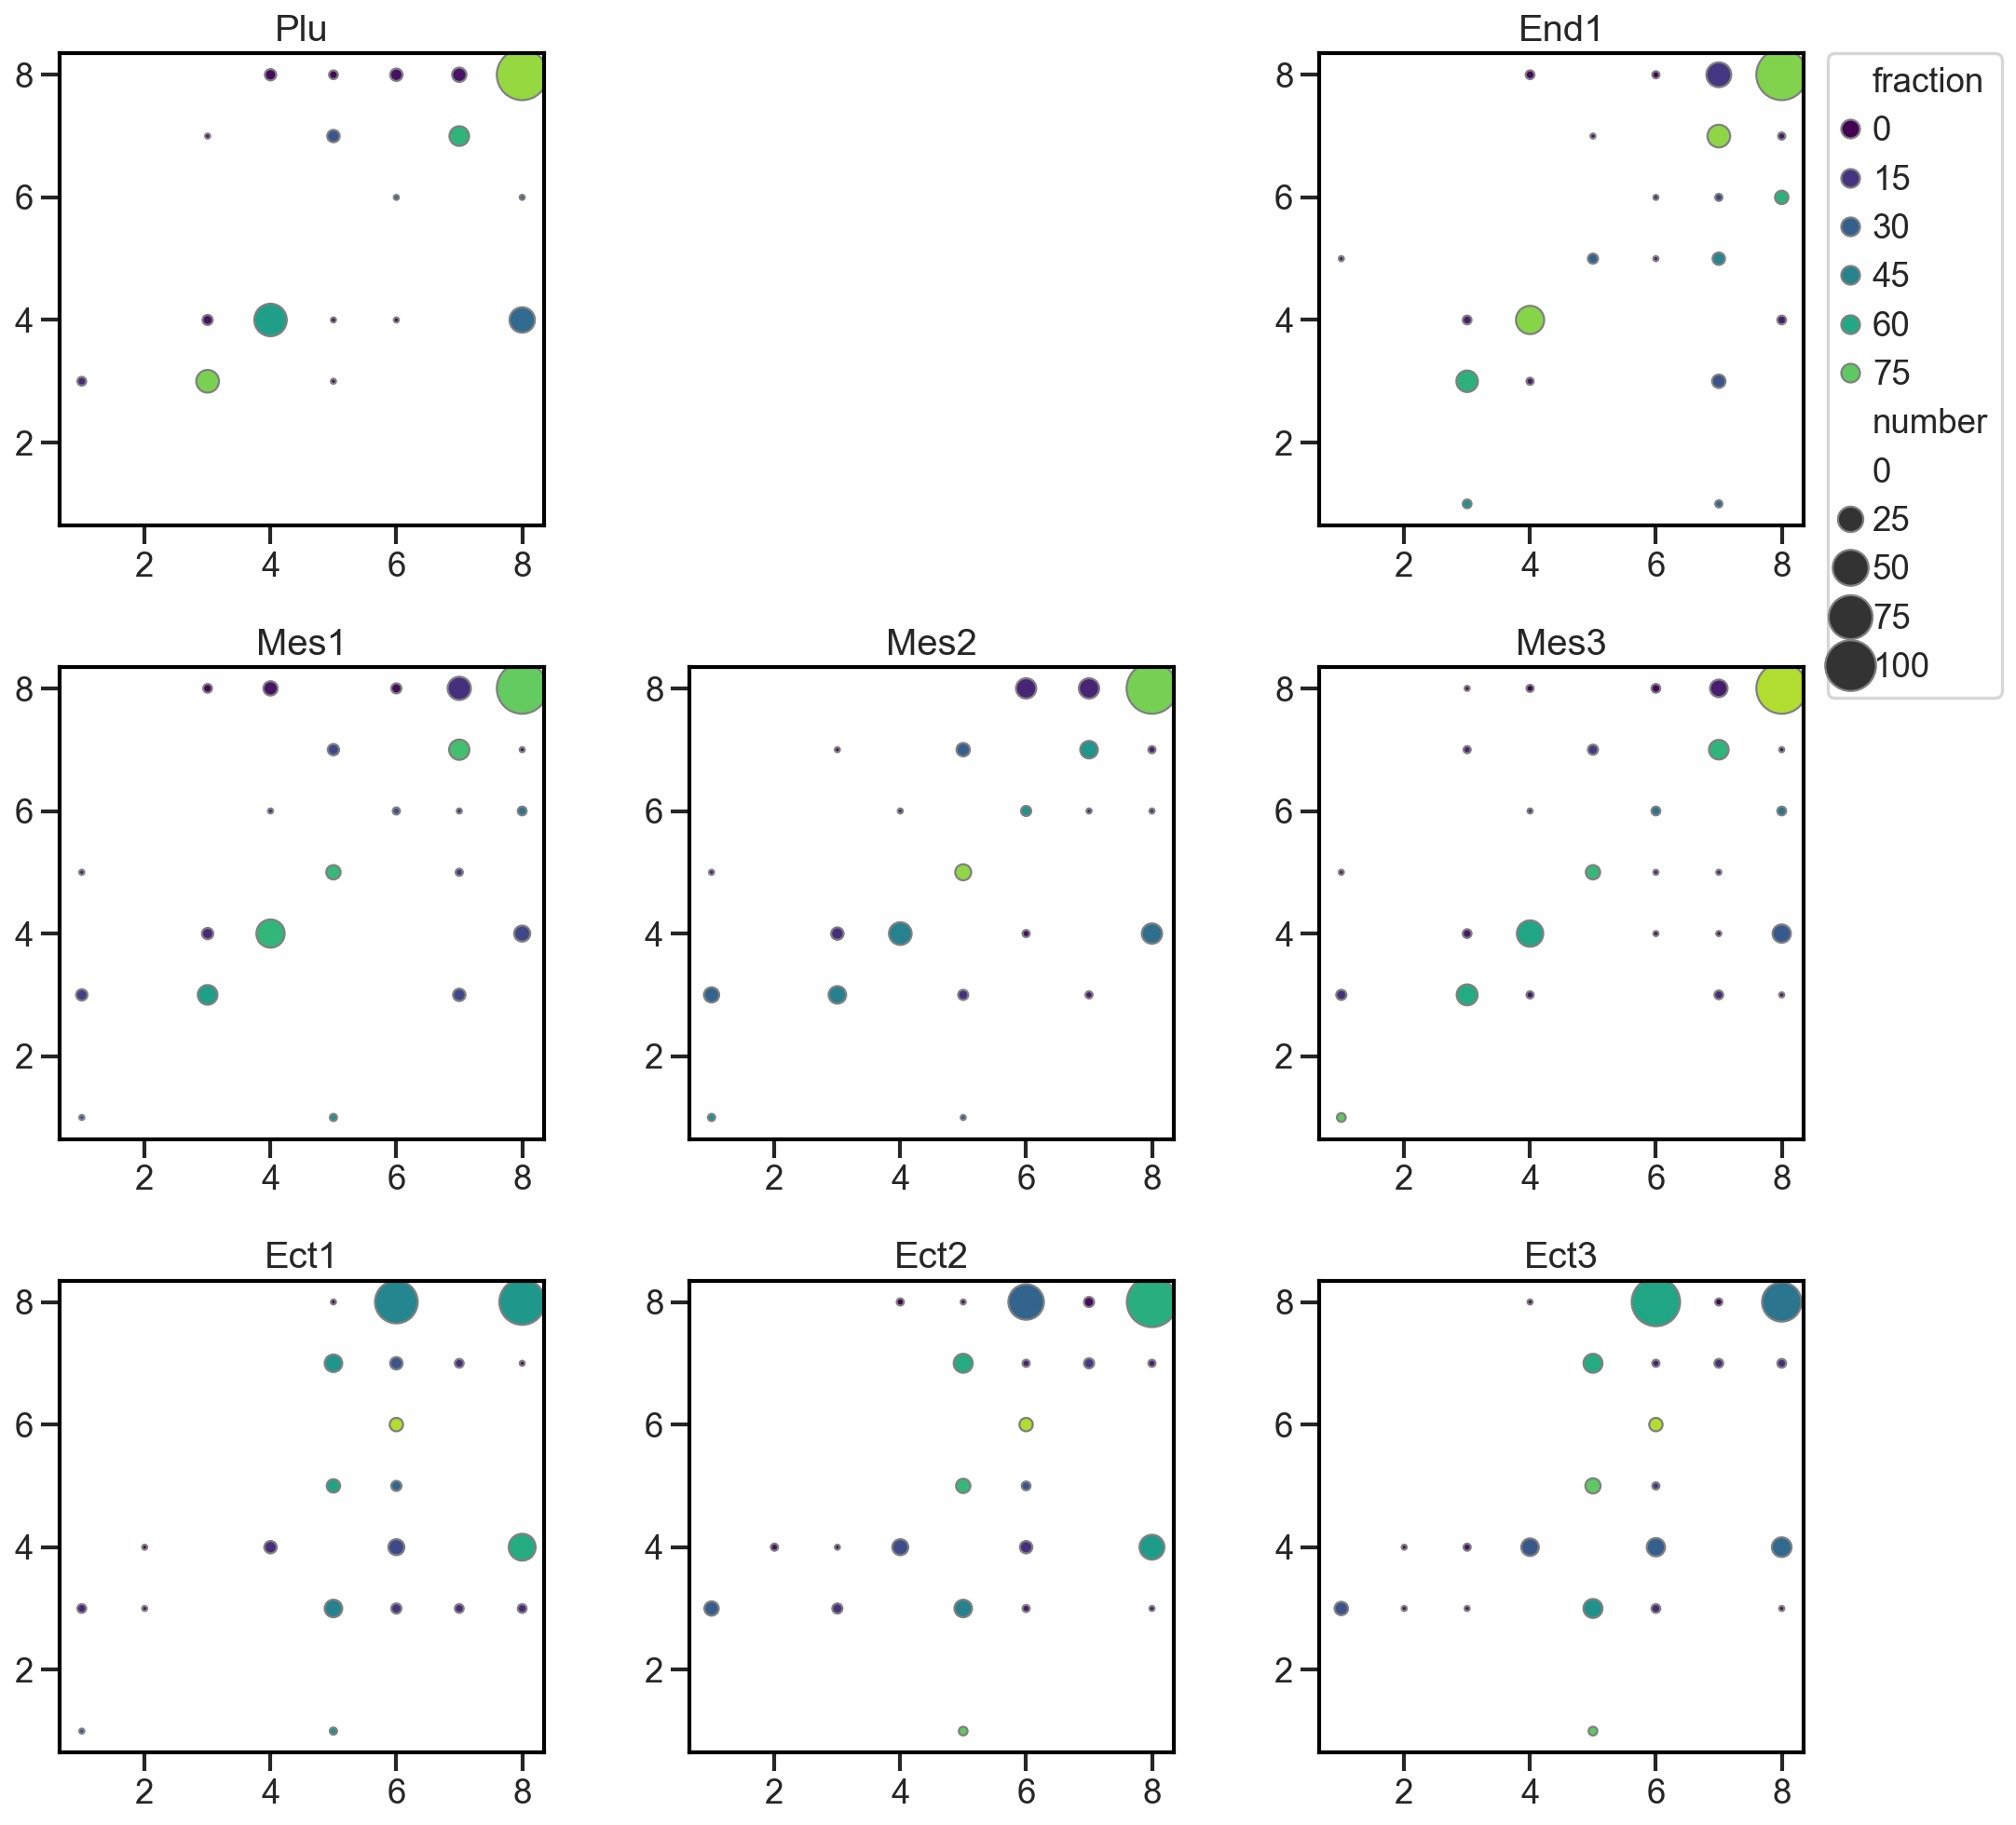

C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\au783837\AppData\Local\anaconda3\envs\Scanpy\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


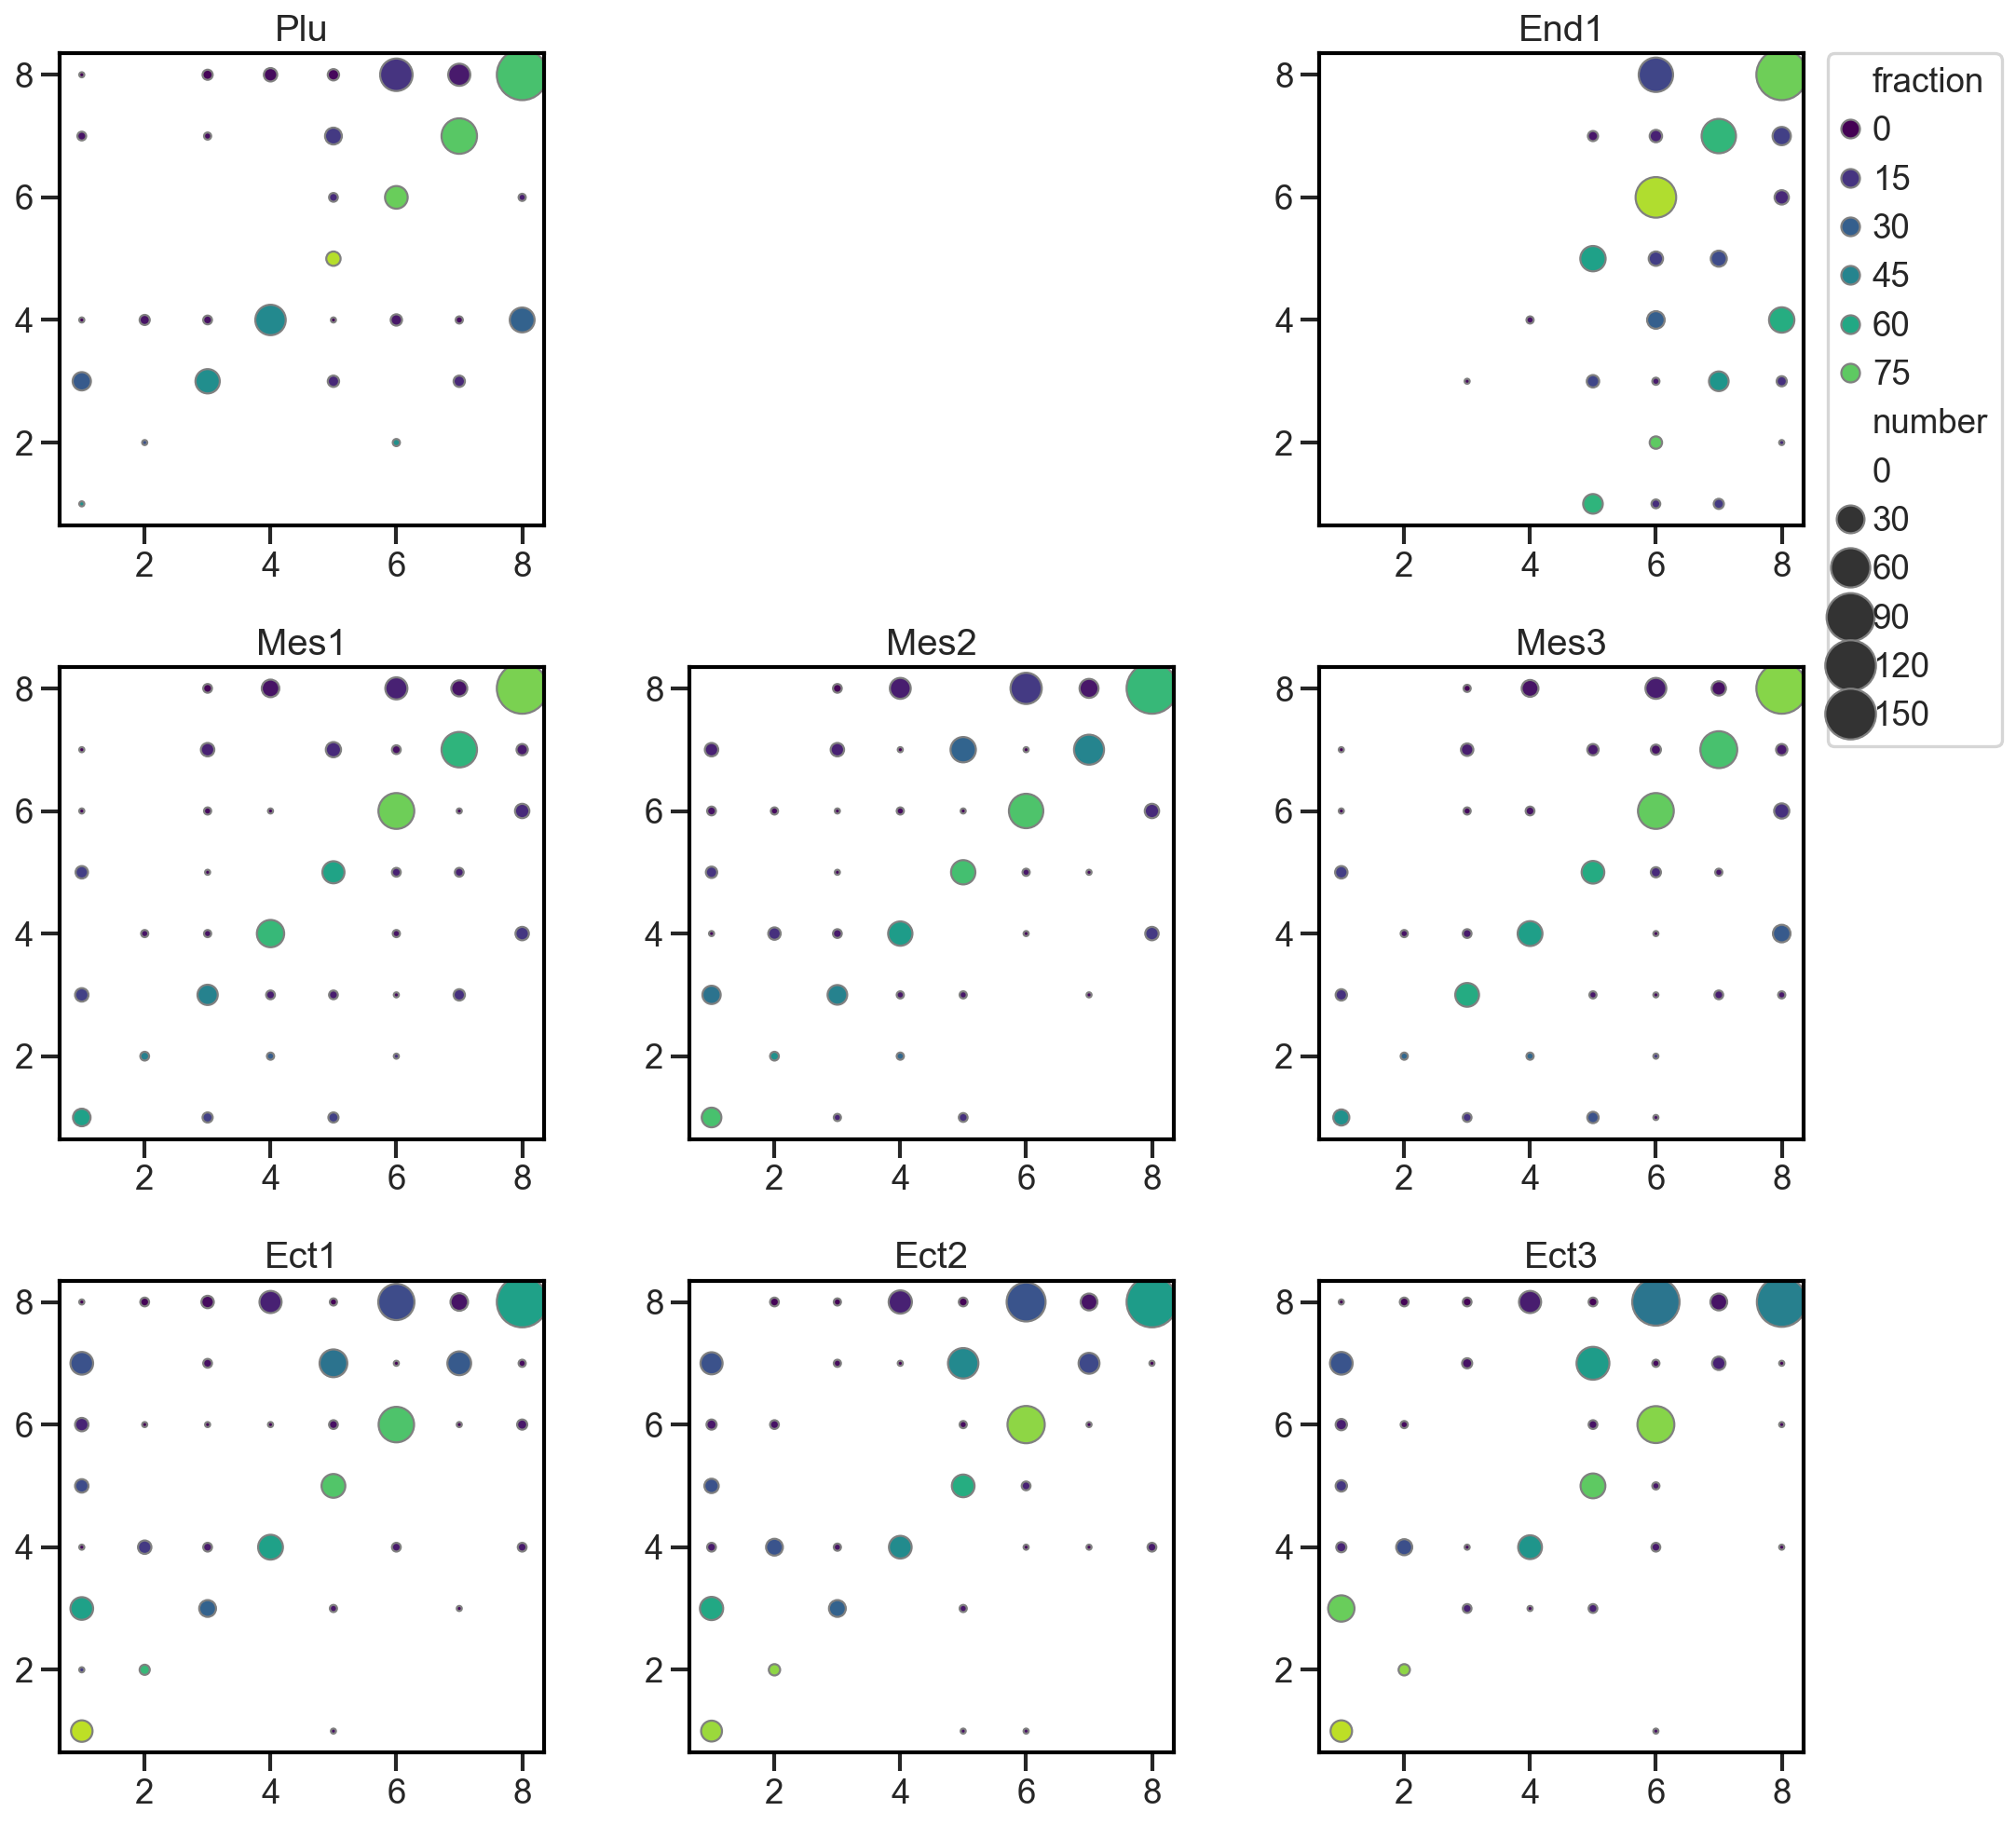

In [52]:
transitiondotplot2('MESvsPLU', geneset=Mset[~Mset.isin(ENDset.append(ECTset))], onlychanging=False, huemax=100, sizemax=100)
transitiondotplot2('ECTvsPLU', geneset=ECTset[~ECTset.isin(ENDset.append(Mset))], onlychanging=False, huemax=100, sizemax=100)
transitiondotplot2('ENDvsPLU', geneset=ENDset[~ENDset.isin(ECTset.append(Mset))], onlychanging=False, huemax=100, sizemax=100)


